In [1]:
from timescale import TimescaleDBManager
from dotenv import load_dotenv
from sqlalchemy import create_engine
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import joblib
import json
import re
from functools import partial

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,accuracy_score, precision_score, recall_score, f1_score,classification_report
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, roc_curve, RocCurveDisplay
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler


from tensorflow.keras import layers, models
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense,BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.models import load_model

from scikeras.wrappers import KerasRegressor
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import optuna
import tensorflow as tf
import seaborn as sns








In [2]:
load_dotenv()
user_env        = os.getenv("USER_DB")
pass_env        = os.getenv("PASS_DB")
host_env        = os.getenv("HOST_DB", "localhost")
port_env        = os.getenv("DB_PORT_EXPOSED", "5432")
db_env          = os.getenv("NAME_DB", "tfm_db")
FOLDER_SALIDA   = os.getenv("FOLDER_SALIDA")
FOLDER_TMP      = os.getenv("FOLDER_TMP")

SEED            = 100#int(os.getenv("SEED"))

db = TimescaleDBManager(
    user=user_env,
    password=pass_env,
    host=host_env,
    port=port_env,
    dbname=db_env
)
db.conectar()
conexion_postgresql = db.connection

#esto es para usar una conexion postgrews para pandas que da un warning indicando que solo esta testeado para sqlalchemy
engine = create_engine(f'postgresql+psycopg2://{user_env}:{pass_env}@{host_env}:{port_env}/{db_env}')

[OK] Conexión establecida con TimescaleDB.


In [4]:
tabla1_origen = 'vectores'
tabla2_origen = 'vectores_logs'
tabla_split   = 'vectores_logs_split'
filename_lista_metric_name_vector2 = f'{FOLDER_SALIDA}/lista_metricas_filtradas_ord(metricas_logs).json'

In [16]:
SQL = f'select * from {tabla1_origen}'
df1 = pd.read_sql(SQL, engine)
df1 = df1.rename(columns={'vector_id':'vector_id1','vector':'vector1','label':'label1'})


SQL = f'select * from {tabla2_origen}'
df2 = pd.read_sql(SQL, engine)
df2 = df2.rename(columns={'vector_id':'vector_id2','vector':'vector2','label':'label2'})


In [17]:
df1

,vector_id1,execution_name,label1,t_rel,vector1
0,90244,light-oauth2-data-1719592986.tar,correct,5.0,"[0.9607689228305228, -0.2773500981126145, -0.2..."
1,90245,light-oauth2-data-1719592986.tar,correct,10.0,"[0.9607689228305228, -0.2773500981126145, -0.2..."
2,90246,light-oauth2-data-1719592986.tar,correct,15.0,"[0.9607689228305228, -0.2773500981126145, -0.2..."
3,90247,light-oauth2-data-1719592986.tar,correct,20.0,"[0.9607689228305228, -0.2773500981126145, -0.2..."
4,90333,light-oauth2-data-1719594842.tar,invalid_code_verifier_format_PKCE_400,535.0,"[0.00692828, 42.989265207455254, 34.7641270035..."
...,...,...,...,...,...
90185,180429,light-oauth2-data-1725866154.tar,delete_user_404_no_user,805.0,"[0.0038457239999999996, -0.2773500981126146, -..."
90186,180430,light-oauth2-data-1725866154.tar,update_password_401_wrong_password,820.0,"[0.0038457239999999996, -0.2773500981126146, -..."
90187,180431,light-oauth2-data-1725866154.tar,update_password_404_user_not_found,835.0,"[0.0038457239999999996, -0.2773500981126146, -..."
90188,180432,light-oauth2-data-1725866154.tar,update_password_400_not_match,850.0,"[0.0038457239999999996, 15.587075513929266, 8...."


In [18]:
df2

,vector_id2,execution_name,label2,t_rel,vector2
0,34618,light-oauth2-data-1719592986.tar,correct,5.0,"[2.661257001557323, 1.4211265378719566, 1.1653..."
1,34619,light-oauth2-data-1719592986.tar,correct,10.0,"[0.2100992369650517, 1.7466463600284912, 0.531..."
2,34620,light-oauth2-data-1719592986.tar,correct,15.0,"[-1.015479645331084, -0.7366048547085009, -1.0..."
3,34621,light-oauth2-data-1719592986.tar,correct,20.0,"[-0.14006615797670136, -0.02046124596412492, 0..."
4,34622,light-oauth2-data-1719592986.tar,correct,25.0,"[-0.14006615797670136, 0.29575800984508005, 0...."
...,...,...,...,...,...
32897,67515,light-oauth2-data-1721981647.tar,get_user_404_no_user,715.0,"[-2.2000106450668584, 1.6967012485934319, -0.7..."
32898,67516,light-oauth2-data-1721981647.tar,get_user_page_400_no_page,730.0,"[0.1855430664514216, 1.7346757617669644, -0.45..."
32899,67517,light-oauth2-data-1721981647.tar,delete_user_404_no_user,745.0,"[-2.2000106450668584, -0.8020217182250066, -1...."
32900,67518,light-oauth2-data-1721981647.tar,update_password_404_user_not_found,770.0,"[-1.404826074560765, 3.2916308018817966, 0.163..."


In [19]:
df_merged = pd.merge(df1, df2, on=['execution_name', 't_rel'], how='inner')


In [30]:
df1[df1['execution_name']=='light-oauth2-data-1725866154.tar'].head(20)

,vector_id1,execution_name,label1,t_rel,vector1
90121,180370,light-oauth2-data-1725866154.tar,correct,10.0,"[0.0, -0.2773500981126146, -0.2773500981126145..."
90126,180369,light-oauth2-data-1725866154.tar,correct,5.0,"[0.0, -0.2773500981126146, -0.2773500981126145..."
90127,180371,light-oauth2-data-1725866154.tar,correct,15.0,"[0.0, -0.2773500981126146, -0.2773500981126145..."
90128,180372,light-oauth2-data-1725866154.tar,correct,20.0,"[0.0, -0.2773500981126146, -0.2773500981126145..."
90129,180373,light-oauth2-data-1725866154.tar,correct,25.0,"[0.0, -0.2773500981126146, -0.2773500981126145..."
90130,180374,light-oauth2-data-1725866154.tar,correct,30.0,"[0.0, -0.2773500981126146, -0.2773500981126145..."
90131,180375,light-oauth2-data-1725866154.tar,correct,35.0,"[0.0, -0.2773500981126146, -0.2773500981126145..."
90132,180376,light-oauth2-data-1725866154.tar,correct,40.0,"[0.0, -0.2773500981126146, -0.2773500981126145..."
90133,180377,light-oauth2-data-1725866154.tar,correct,45.0,"[0.0, -0.2773500981126146, -0.2773500981126145..."
90134,180378,light-oauth2-data-1725866154.tar,correct,50.0,"[0.0, -0.2773500981126146, -0.2773500981126145..."


In [22]:
son_iguales = (df_merged['label1'] == df_merged['label2']).all()

In [25]:
etiquetas_unicas = df1['label1'].unique()
print(etiquetas_unicas)

<StringArray>
[                                      'correct',
         'invalid_code_verifier_format_PKCE_400',
               'code_verifier_too_long_pkce_400',
                'code_verifier_missing_pkce_400',
                  'verification_failed_pkce_400',
      'authorization_code_client_id_missing_400',
                       'update_user_404_no_user',
            'update_password_404_user_not_found',
                 'update_password_400_not_match',
          'access_token_client_secret_wrong_401',
                'register_client_400_clientType',
                   'register_client_404_no_user',
               'update_client_400_clientProfile',
                     'update_client_404_ownerId',
                          'get_user_404_no_user',
                   'delete_client_404_no_client',
                      'get_client_404_no_client',
                   'get_client_page_400_no_page',
             'register_service_400_service_type',
                  'register_service_

In [6]:
lista_label = df['label'].unique().tolist()

In [7]:
len(lista_label)

54

In [21]:
df_result=df[ ['vector_id','execution_name','label'] ].copy()


In [22]:
df_result

,vector_id,execution_name,label
0,3909,light-oauth2-data-1719592986.tar,correct
1,3910,light-oauth2-data-1719592986.tar,correct
2,3911,light-oauth2-data-1719592986.tar,correct
3,3912,light-oauth2-data-1719592986.tar,correct
4,3913,light-oauth2-data-1719592986.tar,correct
...,...,...,...
10096,14005,light-oauth2-data-1720340042.tar,get_user_404_no_user
10097,14006,light-oauth2-data-1720340042.tar,get_user_page_400_no_page
10098,14007,light-oauth2-data-1720340042.tar,delete_user_404_no_user
10099,14008,light-oauth2-data-1720340042.tar,update_password_404_user_not_found


In [10]:
with open(filename_lista_metric_name_vector, "r", encoding="utf-8") as f:
    lista_metric_name_vector = json.load(f)

In [65]:
len(lista_metric_name_vector)

331

# <span style="color:#2ca02c">1. Recuperamos separación ya hecha en conjuntos de train, val y test</span>

In [23]:
SQL=f'select * from {tabla_split}'
df_split = pd.read_sql(SQL, engine)

In [24]:
df_split

,vector_id,split_type
0,3909,train
1,3910,train
2,3911,train
3,3912,train
4,3913,train
...,...,...
10096,14005,train
10097,14006,train
10098,14007,train
10099,14008,train


In [25]:
df_result = pd.merge(df_result, df_split, on="vector_id", how="inner")

In [26]:
df_result

,vector_id,execution_name,label,split_type
0,3909,light-oauth2-data-1719592986.tar,correct,train
1,3910,light-oauth2-data-1719592986.tar,correct,train
2,3911,light-oauth2-data-1719592986.tar,correct,train
3,3912,light-oauth2-data-1719592986.tar,correct,train
4,3913,light-oauth2-data-1719592986.tar,correct,train
...,...,...,...,...
10096,14005,light-oauth2-data-1720340042.tar,get_user_404_no_user,train
10097,14006,light-oauth2-data-1720340042.tar,get_user_page_400_no_page,train
10098,14007,light-oauth2-data-1720340042.tar,delete_user_404_no_user,train
10099,14008,light-oauth2-data-1720340042.tar,update_password_404_user_not_found,train


In [27]:
dic_idx_train = {}
#dic_idx_resto = {}
dic_idx_val   = {}
dic_idx_test  = {}

In [28]:
for label in lista_label:
    idx_train = df_result[  (df_result['label']==label) & (df_result['split_type'] == 'train') ].index.values
    idx_val   = df_result[  (df_result['label']==label) & (df_result['split_type'] == 'val'  ) ].index.values
    idx_test  = df_result[  (df_result['label']==label) & (df_result['split_type'] == 'test') ].index.values
    dic_idx_train[label] = idx_train
    dic_idx_val[label]   = idx_val
    dic_idx_test[label]  = idx_test

<span style="color:#2ca02c"> Convetimos los vectores del df en una matriz, seran los datos que pasemos a los algoritmo   </span>


In [29]:
X_matrix = np.array(df['vector'].tolist())
X_matrix.shape

(10101, 331)

# <span style="color:#2ca02c">2. Preparacion de datos para entrenamiento/test</span>

In [31]:
idx_correct_train = dic_idx_train['correct']
idx_correct_val   = dic_idx_val['correct']
idx_correct_test  = dic_idx_test['correct']

In [32]:
N_datos_test_por_anomalia = int( len(idx_correct_test)  / (len(lista_label)-1) )

In [33]:
idx_test = idx_correct_test.copy()
idx_val  = idx_correct_val.copy()
for label in lista_label:
    if label=='correct':
        continue
    if len(dic_idx_test[label])<N_datos_test_por_anomalia:
        idx_test = np.concatenate((idx_test , dic_idx_test[label]))
        idx_val  = np.concatenate((idx_val  , dic_idx_val[label]))
    else:
        #idx_test.extend(dic_idx_test[label][:N_datos_test_por_anomalia])
        # Corrección: pon los dos arrays dentro de un paréntesis
        idx_test = np.concatenate((idx_test , dic_idx_test[label][:N_datos_test_por_anomalia]))
        idx_val  = np.concatenate((idx_val  , dic_idx_val[label][:N_datos_test_por_anomalia]))
        
X_test  = X_matrix[idx_test]
X_val   = X_matrix[idx_val]

In [34]:
X_correct_train = X_matrix[idx_correct_train]
X_correct_test  = X_matrix[idx_correct_test]

In [35]:
df_result = pd.DataFrame({
    't_rel': df.loc[idx_test, 't_rel'],
    'execution_name': df.loc[idx_correct_test, 'execution_name'],
    'label': df.loc[idx_test, 'label']
})

In [36]:
df_result

,t_rel,execution_name,label
18,235.0,NaN,update_service_404_user_id
24,345.0,NaN,authorization_code_client_id_missing_400
34,505.0,NaN,code_challenge_too_long_pkce_400
38,560.0,NaN,code_verifier_too_long_pkce_400
39,575.0,NaN,code_verifier_missing_pkce_400
...,...,...,...
10003,20.0,light-oauth2-data-1720336447.tar,correct
10004,25.0,light-oauth2-data-1720336447.tar,correct
10007,40.0,light-oauth2-data-1720336447.tar,correct
10008,45.0,light-oauth2-data-1720336447.tar,correct


# <span style="color:#2ca02c">3. N/A</span>

# <span style="color:#2ca02c">4. Clasificacion de anomalias</span>

## <span style="color:#2ca02c">4.1 Clasificador Random Forest con metricas_logs</span>

In [37]:

idx_train = np.array([], dtype=int)
idx_test  = np.array([], dtype=int)

In [38]:
for label in lista_label:
    if label=='correct':
        continue
    idx_train_tmp = dic_idx_train[label]
    idx_train     = np.concatenate((idx_train , idx_train_tmp))
    idx_test_tmp  = dic_idx_test[label]
    idx_test      = np.concatenate((idx_test  , idx_test_tmp ))
    
    

In [39]:
X_anomalia_train = X_matrix[idx_train]
X_anomalia_test  = X_matrix[idx_test]

In [40]:
X_anomalia_train.shape

(4960, 331)

In [41]:
df_result

,t_rel,execution_name,label
18,235.0,NaN,update_service_404_user_id
24,345.0,NaN,authorization_code_client_id_missing_400
34,505.0,NaN,code_challenge_too_long_pkce_400
38,560.0,NaN,code_verifier_too_long_pkce_400
39,575.0,NaN,code_verifier_missing_pkce_400
...,...,...,...
10003,20.0,light-oauth2-data-1720336447.tar,correct
10004,25.0,light-oauth2-data-1720336447.tar,correct
10007,40.0,light-oauth2-data-1720336447.tar,correct
10008,45.0,light-oauth2-data-1720336447.tar,correct


In [42]:
Y_train_etiquetas = df.loc[idx_train , 'label']
Y_test_etiquetas  = df.loc[idx_test  , 'label']

In [43]:
len(Y_train_etiquetas)

4960

In [44]:
df_result

,t_rel,execution_name,label
18,235.0,NaN,update_service_404_user_id
24,345.0,NaN,authorization_code_client_id_missing_400
34,505.0,NaN,code_challenge_too_long_pkce_400
38,560.0,NaN,code_verifier_too_long_pkce_400
39,575.0,NaN,code_verifier_missing_pkce_400
...,...,...,...
10003,20.0,light-oauth2-data-1720336447.tar,correct
10004,25.0,light-oauth2-data-1720336447.tar,correct
10007,40.0,light-oauth2-data-1720336447.tar,correct
10008,45.0,light-oauth2-data-1720336447.tar,correct


In [45]:
X_anomalia_train.shape

(4960, 331)

In [46]:
X_anomalia_train.shape

(4960, 331)

In [47]:
Y_train_etiquetas.shape

(4960,)

In [48]:
# 1. Instanciar el clasificador de tipos de anomalía
clf_anomalias = RandomForestClassifier(random_state=SEED, n_estimators=100)

# 2. Entrenar el modelo con los datos de entrenamiento
clf_anomalias.fit(X_anomalia_train, Y_train_etiquetas)

# 3. Generar las predicciones del tipo de anomalía sobre el conjunto de test
Y_pred_tipos = clf_anomalias.predict(X_anomalia_test)

# 4. Evaluar el rendimiento del clasificador usando las etiquetas reales de test
print("=== REPORTE DE CLASIFICACIÓN DE TIPOS DE ANOMALÍA ===")
print(classification_report(Y_test_etiquetas, Y_pred_tipos))


=== REPORTE DE CLASIFICACIÓN DE TIPOS DE ANOMALÍA ===
                                               precision    recall  f1-score   support

           access_token_auth_header_error_401       0.84      0.68      0.75        31
          access_token_authorization_form_401       0.25      0.29      0.27        35
         access_token_client_id_not_found_404       0.88      0.92      0.90        38
         access_token_client_secret_wrong_401       0.96      0.78      0.86        32
             access_token_form_urlencoded_400       0.16      0.19      0.18        36
          access_token_illegal_grant_type_400       0.81      0.79      0.80        38
access_token_missing_authorization_header_400       0.12      0.09      0.10        34
     authorization_code_client_id_missing_400       0.04      0.03      0.04        31
     authorization_code_invalid_client_id_404       0.17      0.18      0.17        34
      authorization_code_invalid_password_401       0.46      0.68      0.5

## <span style="color:#2ca02c">4.5. Clasificador XGBoost con metricas_logs</span>

In [49]:
Y_train_etiquetas.shape

(4960,)

In [50]:
encoder_etiquetas = LabelEncoder()
Y_train_encoded = encoder_etiquetas.fit_transform(Y_train_etiquetas)
Y_test_encoded = encoder_etiquetas.transform(Y_test_etiquetas)

In [51]:


optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1. Callback de verbose para ver el progreso de Optuna en tiempo real
def print_callback(study, trial):
    print(f"Trial {trial.number} finalizado | Mejor Accuracy actual: {study.best_value:.4f} | Parámetros: {trial.params}")

# 2. Función objetivo de Optuna recibiendo el diccionario externo de configuración
def objective(trial, config):
    params = {
        'random_state': SEED,
        'tree_method': 'hist',
        'eval_metric': 'mlogloss',
        'n_jobs': -1,
        'n_estimators': trial.suggest_categorical('n_estimators', config['n_estimators']),
        'learning_rate': trial.suggest_categorical('learning_rate', config['learning_rate']),
        'max_depth': trial.suggest_categorical('max_depth', config['max_depth']),
        'subsample': trial.suggest_categorical('subsample', config['subsample']),
        'colsample_bytree': trial.suggest_categorical('colsample_bytree', config['colsample_bytree']),
        'min_child_weight': trial.suggest_categorical('min_child_weight', config['min_child_weight']),
        'gamma': trial.suggest_categorical('gamma', config['gamma'])
    }
    
    # Instanciar y entrenar el modelo con los parámetros sugeridos
    model = XGBClassifier(**params)
    model.fit(X_anomalia_train, Y_train_encoded)
    
    # Evaluar el rendimiento en test
    preds = model.predict(X_anomalia_test)
    accuracy = accuracy_score(Y_test_encoded, preds)
    
    trial.set_user_attr('accuracy', accuracy)
    return accuracy

# 3. Definición externa de los hiperparámetros a probar
params_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    'min_child_weight': [1, 3],
    'gamma': [0.0, 0.1]
}

# 4. Crear el estudio
study_xgb = optuna.create_study(direction='maximize')

# 5. Enlazar la función con los parámetros mediante partial
objective_func_xgb = partial(objective, config=params_grid_xgb)

# 6. Ejecutar pasando el callback de verbose
print("=== INICIANDO OPTIMIZACIÓN DE XGBOOST CON OPTUNA ===")
study_xgb.optimize(objective_func_xgb, n_trials=30, callbacks=[print_callback], n_jobs=-1)

# 7. Resultados finales y entrenamiento del modelo definitivo
print("\n=== MEJOR COMBINACIÓN ENCONTRADA (XGBOOST) ===")
print(study_xgb.best_params)
print(f"Mejor Accuracy: {study_xgb.best_value:.4f}")

# Reconstruir el modelo final con los mejores parámetros óptimos
mejores_params = study_xgb.best_params.copy()
mejores_params['random_state'] = SEED
mejores_params['tree_method'] = 'hist'
mejores_params['eval_metric'] = 'mlogloss'

clf_anomalias = XGBClassifier(**mejores_params, n_jobs=-1, verbosity=1)
clf_anomalias.fit(X_anomalia_train, Y_train_encoded)

=== INICIANDO OPTIMIZACIÓN DE XGBOOST CON OPTUNA ===
Trial 27 finalizado | Mejor Accuracy actual: 0.4104 | Parámetros: {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 4, 'subsample': 0.9, 'colsample_bytree': 0.7, 'min_child_weight': 3, 'gamma': 0.1}
Trial 21 finalizado | Mejor Accuracy actual: 0.4175 | Parámetros: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 4, 'subsample': 0.7, 'colsample_bytree': 1.0, 'min_child_weight': 1, 'gamma': 0.1}
Trial 13 finalizado | Mejor Accuracy actual: 0.4175 | Parámetros: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 6, 'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight': 3, 'gamma': 0.0}
Trial 12 finalizado | Mejor Accuracy actual: 0.4175 | Parámetros: {'n_estimators': 100, 'learning_rate': 0.01, 'max_depth': 8, 'subsample': 0.7, 'colsample_bytree': 0.7, 'min_child_weight': 3, 'gamma': 0.0}
Trial 8 finalizado | Mejor Accuracy actual: 0.4253 | Parámetros: {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

In [52]:



clf_anomalias = XGBClassifier(
    random_state=SEED, 
    n_estimators=300, 
    learning_rate=0.01,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=1.0,
    min_child_weight=1,
    gamma=0.0,
    eval_metric='mlogloss',
    verbosity=1,
    n_jobs=-1
)

# 2. Entrenar el modelo con los datos de entrenamiento
clf_anomalias.fit(X_anomalia_train, Y_train_encoded)

# 3. Generar las predicciones del tipo de anomalía sobre el conjunto de test
Y_pred_encoded = clf_anomalias.predict(X_anomalia_test)

# (Opcional) Si quieres volver a ver las predicciones con sus nombres de texto originales en el report:
Y_pred_tipos = encoder_etiquetas.inverse_transform(Y_pred_encoded)

# 4. Evaluar el rendimiento del clasificador usando las etiquetas reales de test
print("=== REPORTE DE CLASIFICACIÓN DE TIPOS DE ANOMALÍA (XGBOOST) ===")
print(classification_report(Y_test_etiquetas, Y_pred_tipos))


=== REPORTE DE CLASIFICACIÓN DE TIPOS DE ANOMALÍA (XGBOOST) ===
                                               precision    recall  f1-score   support

           access_token_auth_header_error_401       0.84      0.68      0.75        31
          access_token_authorization_form_401       0.20      0.26      0.22        35
         access_token_client_id_not_found_404       0.97      0.87      0.92        38
         access_token_client_secret_wrong_401       0.90      0.81      0.85        32
             access_token_form_urlencoded_400       0.36      0.28      0.31        36
          access_token_illegal_grant_type_400       0.91      0.79      0.85        38
access_token_missing_authorization_header_400       0.35      0.26      0.30        34
     authorization_code_client_id_missing_400       0.04      0.03      0.04        31
     authorization_code_invalid_client_id_404       0.40      0.35      0.38        34
      authorization_code_invalid_password_401       0.66      0.6

In [ ]:
Python





In [53]:

optuna.logging.set_verbosity(optuna.logging.WARNING)

from tqdm import tqdm

N_trials=16
# 1. Crear una barra de progreso global basada en el número total de trials
pbar = tqdm(total=N_trials, desc="Optimizando XGBoost")



# 1. Callback de verbose para ver el progreso de Optuna en tiempo real
def print_callback(study, trial):
    print(f"Trial {trial.number} finalizado | Mejor Accuracy actual: {study.best_value:.4f} | Parámetros: {trial.params}")
    pbar.update(1)
    pbar.set_postfix({
        "Mejor_Acc": f"{study.best_value:.4f}",
        "Trial": trial.number
    })
    
# 2. Función objetivo de Optuna recibiendo el diccionario externo de configuración
def objective(trial, config):
    params = {
        'random_state': SEED,
        'tree_method': 'hist',
        'eval_metric': 'mlogloss',
        'n_jobs': -1,
        'n_estimators': trial.suggest_categorical('n_estimators', config['n_estimators']),
        'learning_rate': trial.suggest_categorical('learning_rate', config['learning_rate']),
        'max_depth': trial.suggest_categorical('max_depth', config['max_depth']),
        'subsample': trial.suggest_categorical('subsample', config['subsample']),
        'colsample_bytree': trial.suggest_categorical('colsample_bytree', config['colsample_bytree']),
        'min_child_weight': trial.suggest_categorical('min_child_weight', config['min_child_weight']),
        'gamma': trial.suggest_categorical('gamma', config['gamma'])
    }
    
    # Instanciar y entrenar el modelo con los parámetros sugeridos
    model = XGBClassifier(**params)
    model.fit(X_anomalia_train, Y_train_encoded)
    
    # Evaluar el rendimiento en test
    preds = model.predict(X_anomalia_test)
    accuracy = accuracy_score(Y_test_encoded, preds)
    
    trial.set_user_attr('accuracy', accuracy)
    return accuracy

# 3. Definición externa de los hiperparámetros a probar
params_grid_xgb = {
    'n_estimators': [ 200, 300, 400],
    'learning_rate': [0.05, 0.01, 0.05],
    'max_depth': [6, 8, 10],
    'subsample': [0.7, 0.8,0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 2,  3],
    'gamma': [0.0, 0.1, 0.2]
}

# 4. Crear el estudio
study_xgb = optuna.create_study(direction='maximize')

# 5. Enlazar la función con los parámetros mediante partial
objective_func_xgb = partial(objective, config=params_grid_xgb)

# 6. Ejecutar pasando el callback de verbose
print("=== INICIANDO OPTIMIZACIÓN DE XGBOOST CON OPTUNA ===")
#study_xgb.optimize(objective_func_xgb, n_trials=30, callbacks=[print_callback], n_jobs=-1)
try:
    study_xgb.optimize(objective_func_xgb, n_trials=N_trials, callbacks=[print_callback], n_jobs=1)
finally:
    pbar.close() # Asegurar que la barra se cierre correctamente al terminar
    
# 7. Resultados finales y entrenamiento del modelo definitivo
print("\n=== MEJOR COMBINACIÓN ENCONTRADA (XGBOOST) ===")
print(study_xgb.best_params)
print(f"Mejor Accuracy: {study_xgb.best_value:.4f}")

# Reconstruir el modelo final con los mejores parámetros óptimos
mejores_params = study_xgb.best_params.copy()
mejores_params['random_state'] = SEED
mejores_params['tree_method'] = 'hist'
mejores_params['eval_metric'] = 'mlogloss'
mejores_params['n_jobs'] = -1


Optimizando XGBoost:   0%|          | 0/16 [00:00<?, ?it/s]

=== INICIANDO OPTIMIZACIÓN DE XGBOOST CON OPTUNA ===


Optimizando XGBoost:   6%|▋         | 1/16 [00:38<09:40, 38.69s/it, Mejor_Acc=0.4133, Trial=0]

Trial 0 finalizado | Mejor Accuracy actual: 0.4133 | Parámetros: {'n_estimators': 200, 'learning_rate': 0.01, 'max_depth': 8, 'subsample': 0.8, 'colsample_bytree': 1.0, 'min_child_weight': 1, 'gamma': 0.2}


Optimizando XGBoost:  12%|█▎        | 2/16 [01:31<10:56, 46.89s/it, Mejor_Acc=0.4133, Trial=1]

Trial 1 finalizado | Mejor Accuracy actual: 0.4133 | Parámetros: {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 10, 'subsample': 0.7, 'colsample_bytree': 1.0, 'min_child_weight': 1, 'gamma': 0.1}


Optimizando XGBoost:  19%|█▉        | 3/16 [02:17<10:08, 46.79s/it, Mejor_Acc=0.4133, Trial=2]

Trial 2 finalizado | Mejor Accuracy actual: 0.4133 | Parámetros: {'n_estimators': 400, 'learning_rate': 0.05, 'max_depth': 8, 'subsample': 0.8, 'colsample_bytree': 0.7, 'min_child_weight': 2, 'gamma': 0.1}


Optimizando XGBoost:  25%|██▌       | 4/16 [02:50<08:14, 41.22s/it, Mejor_Acc=0.4169, Trial=3]

Trial 3 finalizado | Mejor Accuracy actual: 0.4169 | Parámetros: {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 8, 'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight': 1, 'gamma': 0.1}


Optimizando XGBoost:  31%|███▏      | 5/16 [03:27<07:16, 39.67s/it, Mejor_Acc=0.4169, Trial=4]

Trial 4 finalizado | Mejor Accuracy actual: 0.4169 | Parámetros: {'n_estimators': 400, 'learning_rate': 0.05, 'max_depth': 8, 'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight': 1, 'gamma': 0.1}


Optimizando XGBoost:  38%|███▊      | 6/16 [04:05<06:31, 39.13s/it, Mejor_Acc=0.4187, Trial=5]

Trial 5 finalizado | Mejor Accuracy actual: 0.4187 | Parámetros: {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 6, 'subsample': 1.0, 'colsample_bytree': 0.8, 'min_child_weight': 1, 'gamma': 0.0}


Optimizando XGBoost:  44%|████▍     | 7/16 [04:50<06:09, 41.07s/it, Mejor_Acc=0.4217, Trial=6]

Trial 6 finalizado | Mejor Accuracy actual: 0.4217 | Parámetros: {'n_estimators': 300, 'learning_rate': 0.01, 'max_depth': 8, 'subsample': 1.0, 'colsample_bytree': 0.7, 'min_child_weight': 2, 'gamma': 0.1}


Optimizando XGBoost:  50%|█████     | 8/16 [05:50<06:16, 47.03s/it, Mejor_Acc=0.4217, Trial=7]

Trial 7 finalizado | Mejor Accuracy actual: 0.4217 | Parámetros: {'n_estimators': 400, 'learning_rate': 0.05, 'max_depth': 10, 'subsample': 0.7, 'colsample_bytree': 1.0, 'min_child_weight': 1, 'gamma': 0.0}


Optimizando XGBoost:  56%|█████▋    | 9/16 [07:12<06:44, 57.85s/it, Mejor_Acc=0.4217, Trial=8]

Trial 8 finalizado | Mejor Accuracy actual: 0.4217 | Parámetros: {'n_estimators': 400, 'learning_rate': 0.01, 'max_depth': 10, 'subsample': 1.0, 'colsample_bytree': 0.9, 'min_child_weight': 1, 'gamma': 0.1}


Optimizando XGBoost:  62%|██████▎   | 10/16 [07:56<05:22, 53.82s/it, Mejor_Acc=0.4217, Trial=9]

Trial 9 finalizado | Mejor Accuracy actual: 0.4217 | Parámetros: {'n_estimators': 400, 'learning_rate': 0.05, 'max_depth': 10, 'subsample': 0.9, 'colsample_bytree': 0.7, 'min_child_weight': 1, 'gamma': 0.1}


Optimizando XGBoost:  69%|██████▉   | 11/16 [08:22<03:46, 45.22s/it, Mejor_Acc=0.4217, Trial=10]

Trial 10 finalizado | Mejor Accuracy actual: 0.4217 | Parámetros: {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 6, 'subsample': 0.9, 'colsample_bytree': 0.7, 'min_child_weight': 2, 'gamma': 0.2}


Optimizando XGBoost:  75%|███████▌  | 12/16 [09:00<02:52, 43.09s/it, Mejor_Acc=0.4217, Trial=11]

Trial 11 finalizado | Mejor Accuracy actual: 0.4217 | Parámetros: {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 6, 'subsample': 1.0, 'colsample_bytree': 0.8, 'min_child_weight': 3, 'gamma': 0.0}


Optimizando XGBoost:  81%|████████▏ | 13/16 [09:40<02:05, 41.88s/it, Mejor_Acc=0.4217, Trial=12]

Trial 12 finalizado | Mejor Accuracy actual: 0.4217 | Parámetros: {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 6, 'subsample': 1.0, 'colsample_bytree': 0.8, 'min_child_weight': 2, 'gamma': 0.0}


Optimizando XGBoost:  88%|████████▊ | 14/16 [10:17<01:21, 40.52s/it, Mejor_Acc=0.4217, Trial=13]

Trial 13 finalizado | Mejor Accuracy actual: 0.4217 | Parámetros: {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 6, 'subsample': 1.0, 'colsample_bytree': 0.8, 'min_child_weight': 3, 'gamma': 0.0}


Optimizando XGBoost:  94%|█████████▍| 15/16 [11:00<00:41, 41.42s/it, Mejor_Acc=0.4217, Trial=14]

Trial 14 finalizado | Mejor Accuracy actual: 0.4217 | Parámetros: {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 8, 'subsample': 1.0, 'colsample_bytree': 0.9, 'min_child_weight': 2, 'gamma': 0.0}


Optimizando XGBoost: 100%|██████████| 16/16 [11:31<00:00, 43.21s/it, Mejor_Acc=0.4217, Trial=15]

Trial 15 finalizado | Mejor Accuracy actual: 0.4217 | Parámetros: {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 6, 'subsample': 1.0, 'colsample_bytree': 0.8, 'min_child_weight': 2, 'gamma': 0.2}

=== MEJOR COMBINACIÓN ENCONTRADA (XGBOOST) ===
{'n_estimators': 300, 'learning_rate': 0.01, 'max_depth': 8, 'subsample': 1.0, 'colsample_bytree': 0.7, 'min_child_weight': 2, 'gamma': 0.1}
Mejor Accuracy: 0.4217


In [54]:
#entrenamiento con hiperparametros optimizados
clf_anomalias_opt = XGBClassifier(**mejores_params)
clf_anomalias_opt.fit(X_anomalia_train, Y_train_encoded)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

In [55]:
# Predicción y reporte final
Y_pred_encoded_opt = clf_anomalias_opt.predict(X_anomalia_test)
Y_pred_tipos_opt = encoder_etiquetas.inverse_transform(Y_pred_encoded_opt)
Y_pred_probabilidades = clf_anomalias_opt.predict_proba(X_anomalia_test)



In [56]:
print("\n=== REPORTE DE CLASIFICACIÓN (XGBOOST OPTIMIZADO) ===")
print(classification_report(Y_test_etiquetas, Y_pred_tipos_opt))


=== REPORTE DE CLASIFICACIÓN (XGBOOST OPTIMIZADO) ===
                                               precision    recall  f1-score   support

           access_token_auth_header_error_401       0.91      0.68      0.78        31
          access_token_authorization_form_401       0.20      0.29      0.24        35
         access_token_client_id_not_found_404       0.94      0.87      0.90        38
         access_token_client_secret_wrong_401       0.87      0.81      0.84        32
             access_token_form_urlencoded_400       0.27      0.19      0.23        36
          access_token_illegal_grant_type_400       0.94      0.79      0.86        38
access_token_missing_authorization_header_400       0.17      0.12      0.14        34
     authorization_code_client_id_missing_400       0.09      0.06      0.07        31
     authorization_code_invalid_client_id_404       0.28      0.29      0.29        34
      authorization_code_invalid_password_401       0.68      0.66      0.

<span style="color:#2ca02c">XGBoost proporciona las probabilidades de cada clase posible</span>

In [63]:
X_anomalia_train.shape

(4960, 331)

In [67]:


# # 1. Asegúrate de tener guardados los nombres de tus características combinadas
# # (Por ejemplo, las columnas del DataFrame X_train)
feature_names = lista_metric_name_vector.copy()

# 2. Extraer las importancias (por defecto usa 'gain' si se configura, o 'weight')
importancias = clf_anomalias_opt.feature_importances_

# 3. Crear un DataFrame para ordenarlas cómodamente
df_importancias = pd.DataFrame({
    'caracteristica': feature_names,
    'importancia': importancias
}).sort_values(by='importancia', ascending=False).reset_index(drop=True)

# Ver el Top 20 de características más importantes
print(df_importancias.head(50))

# Opcional: Ver cuántas características tienen importancia cero (ruido puro)
caracteristicas_cero = df_importancias[df_importancias['importancia'] == 0.0]
print(f"Características con importancia cero: {len(caracteristicas_cero)}")

                            caracteristica  importancia
0         light-oauth2-oauth2-client-1(20)     0.090438
1          light-oauth2-oauth2-token-1(24)     0.069981
2         light-oauth2-oauth2-client-1(21)     0.061187
3         light-oauth2-oauth2-client-1(23)     0.058919
4         light-oauth2-oauth2-client-1(22)     0.057559
5         light-oauth2-oauth2-client-1(19)     0.054357
6         light-oauth2-oauth2-client-1(16)     0.051075
7          light-oauth2-oauth2-token-1(11)     0.047084
8         light-oauth2-oauth2-client-1(17)     0.042749
9         light-oauth2-oauth2-client-1(32)     0.036828
10         light-oauth2-oauth2-token-1(27)     0.032332
11          light-oauth2-oauth2-token-1(9)     0.032184
12        light-oauth2-oauth2-client-1(14)     0.028923
13         light-oauth2-oauth2-token-1(23)     0.016679
14         light-oauth2-oauth2-token-1(62)     0.012255
15        light-oauth2-oauth2-client-1(18)     0.009770
16         light-oauth2-oauth2-token-1(44)     0

In [72]:
indices_ordenados = [int(i) for i in np.argsort(clf_anomalias_opt.feature_importances_)[::-1]]

In [80]:
n_min = 10
n_max = 100
lista_result = []


for N_feat in range(n_min, n_max + 1):
    # Seleccionar los primeros 'n' índices más importantes
    current_indices = indices_ordenados[:N_feat]
    
    # Filtrar tus datasets (asumiendo que X_train y X_test son DataFrames de Pandas)
    X_anomalia_train_sub = X_anomalia_train[:, current_indices]
    X_anomalia_test_sub  = X_anomalia_test[:, current_indices]
    
    clf_anomalias_opt = XGBClassifier(**mejores_params)
    clf_anomalias_opt.fit(X_anomalia_train_sub, Y_train_encoded)
    # Predicción y reporte final
    Y_pred_encoded_opt = clf_anomalias_opt.predict(X_anomalia_test_sub)
    Y_pred_tipos_opt = encoder_etiquetas.inverse_transform(Y_pred_encoded_opt)
    Y_pred_probabilidades = clf_anomalias_opt.predict_proba(X_anomalia_test_sub)


    reporte_dict = classification_report(Y_test_etiquetas, Y_pred_tipos_opt, output_dict=True)

    
    # Si quieres guardarlo para comparar después, extraemos las métricas globales clave:
    accuracy = reporte_dict['accuracy']
    macro_f1 = reporte_dict['macro avg']['f1-score']
    weighted_f1 = reporte_dict['weighted avg']['f1-score']
    
    lista_result.append({
        'n_features': N_feat,
        'accuracy': accuracy,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'reporte_completo': reporte_dict # Guarda todo el detalle por clase si lo necesitas
    })

    #print(f"\n=== REPORTE DE CLASIFICACIÓN (XGBOOST OPTIMIZADO) ===\nN_features={N_feat}")
    #print(classification_report(Y_test_etiquetas, Y_pred_tipos_opt))
    print(f"{N_feat:<8} | {accuracy:<10.4f} | {macro_f1:<10.4f}")

    

D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning

10       | 0.1626     | 0.1301    


D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning

11       | 0.1751     | 0.1454    


D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning

12       | 0.1751     | 0.1452    


D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning

13       | 0.1757     | 0.1434    


D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning

14       | 0.1817     | 0.1496    


D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning

15       | 0.1840     | 0.1516    


D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning

16       | 0.1840     | 0.1515    


D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning

17       | 0.1888     | 0.1570    


D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning

18       | 0.2251     | 0.2048    


D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning

19       | 0.2501     | 0.2289    


D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning

20       | 0.2531     | 0.2320    


D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning

21       | 0.2770     | 0.2557    


D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning

22       | 0.2841     | 0.2638    


D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\backup onedrive gva\PERSONAL\master_bigdata_VIU\TFM\tfm-microservices-anomaly-detection\server1\venv_tf\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning

23       | 0.2984     | 0.2901    
24       | 0.3097     | 0.3022    
25       | 0.3240     | 0.3215    
26       | 0.3365     | 0.3239    
27       | 0.3532     | 0.3470    
28       | 0.3603     | 0.3531    
29       | 0.3681     | 0.3638    
30       | 0.3859     | 0.3821    
31       | 0.3770     | 0.3753    
32       | 0.3961     | 0.3908    
33       | 0.3907     | 0.3900    
34       | 0.3919     | 0.3865    
35       | 0.3985     | 0.3940    
36       | 0.3943     | 0.3901    
37       | 0.4008     | 0.3946    
38       | 0.4044     | 0.3991    
39       | 0.4080     | 0.4005    
40       | 0.4139     | 0.4084    
41       | 0.4133     | 0.4109    
42       | 0.4211     | 0.4160    
43       | 0.4139     | 0.4133    
44       | 0.4247     | 0.4195    
45       | 0.4157     | 0.4079    
46       | 0.4253     | 0.4206    
47       | 0.4235     | 0.4161    
48       | 0.4270     | 0.4232    
49       | 0.4229     | 0.4208    
50       | 0.4306     | 0.4306    
51       | 0.4264   

In [81]:
N_feat=56
# Seleccionar los primeros 'n' índices más importantes
current_indices = indices_ordenados[:N_feat]

# Filtrar tus datasets (asumiendo que X_train y X_test son DataFrames de Pandas)
X_anomalia_train_sub = X_anomalia_train[:, current_indices]
X_anomalia_test_sub  = X_anomalia_test[:, current_indices]

clf_anomalias_opt = XGBClassifier(**mejores_params)
clf_anomalias_opt.fit(X_anomalia_train_sub, Y_train_encoded)
# Predicción y reporte final
Y_pred_encoded_opt = clf_anomalias_opt.predict(X_anomalia_test_sub)
Y_pred_tipos_opt = encoder_etiquetas.inverse_transform(Y_pred_encoded_opt)
Y_pred_probabilidades = clf_anomalias_opt.predict_proba(X_anomalia_test_sub)


reporte_dict = classification_report(Y_test_etiquetas, Y_pred_tipos_opt, output_dict=True)


# Si quieres guardarlo para comparar después, extraemos las métricas globales clave:
accuracy = reporte_dict['accuracy']
macro_f1 = reporte_dict['macro avg']['f1-score']
weighted_f1 = reporte_dict['weighted avg']['f1-score']

lista_result.append({
    'n_features': N_feat,
    'accuracy': accuracy,
    'macro_f1': macro_f1,
    'weighted_f1': weighted_f1,
    'reporte_completo': reporte_dict # Guarda todo el detalle por clase si lo necesitas
})

print(f"\n=== REPORTE DE CLASIFICACIÓN (XGBOOST OPTIMIZADO) ===\nN_features={N_feat}")
print(classification_report(Y_test_etiquetas, Y_pred_tipos_opt))
print(f"{N_feat:<8} | {accuracy:<10.4f} | {macro_f1:<10.4f}")



=== REPORTE DE CLASIFICACIÓN (XGBOOST OPTIMIZADO) ===
N_features=56
                                               precision    recall  f1-score   support

           access_token_auth_header_error_401       0.92      0.71      0.80        31
          access_token_authorization_form_401       0.25      0.29      0.27        35
         access_token_client_id_not_found_404       0.94      0.84      0.89        38
         access_token_client_secret_wrong_401       0.81      0.81      0.81        32
             access_token_form_urlencoded_400       0.44      0.31      0.36        36
          access_token_illegal_grant_type_400       0.88      0.79      0.83        38
access_token_missing_authorization_header_400       0.24      0.18      0.20        34
     authorization_code_client_id_missing_400       0.08      0.06      0.07        31
     authorization_code_invalid_client_id_404       0.32      0.32      0.32        34
      authorization_code_invalid_password_401       0.63    

In [51]:
# Índice de la muestra que quieres consultar
indice_muestra = 51

# 1. Obtener la etiqueta real de esa muestra en formato de texto original
etiqueta_real = Y_test_etiquetas.iloc[indice_muestra] if hasattr(Y_test_etiquetas, 'iloc') else Y_test_etiquetas[indice_muestra]

# 2. Obtener las probabilidades de todas las clases para el conjunto de test
probabilidades = clf_anomalias_opt.predict_proba(X_anomalia_test)
probabilidades_muestra = probabilidades[indice_muestra]

# 3. Obtener los nombres originales de las clases desde el LabelEncoder
nombres_clases = encoder_etiquetas.classes_

# 4. Crear un DataFrame para ordenar y visualizar claramente cada clase con su probabilidad
df_probabilidades = pd.DataFrame({
    'Clase_Anomalia': nombres_clases,
    'Probabilidad': probabilidades_muestra
})

# Ordenar de mayor a menor probabilidad
df_probabilidades = df_probabilidades.sort_values(by='Probabilidad', ascending=False).reset_index(drop=True)

# 5. Añadir columna que marque con una "X" si coincide con la etiqueta real
df_probabilidades['Real'] = df_probabilidades['Clase_Anomalia'].apply(lambda x: 'X' if x == etiqueta_real else '')

# 6. Calcular la probabilidad acumulada y marcar las clases que entran en el 95%
df_probabilidades['Probabilidad_Acumulada'] = df_probabilidades['Probabilidad'].cumsum()

# Creamos una máscara para identificar el 95% (asegurando que al menos entre la primera opción)
mask_95 = df_probabilidades['Probabilidad_Acumulada'] <= 0.95
if not mask_95.any():
    mask_95.iloc[0] = True
else:
    # Incluir también la primera que cruza el umbral del 95% si se desea precisión exacta en el corte
    idx_corte = mask_95[mask_95].index[-1]
    if idx_corte + 1 < len(df_probabilidades):
        mask_95.iloc[idx_corte + 1] = True

df_probabilidades['En_95%_Probabilidad'] = mask_95

# Verificar si la etiqueta real está dentro de las filas marcadas con True en el 95%
clases_en_95 = df_probabilidades[df_probabilidades['En_95%_Probabilidad']]['Clase_Anomalia'].values
acierto_en_95 = etiqueta_real in clases_en_95

# Formatear la probabilidad como porcentaje para la visualización final
df_probabilidades['Probabilidad (%)'] = (df_probabilidades['Probabilidad'] * 100).round(2).astype(str) + '%'
df_probabilidades['Acumulada (%)'] = (df_probabilidades['Probabilidad_Acumulada'] * 100).round(2).astype(str) + '%'

# 7. Mostrar resultados
print(f"=== ETIQUETA REAL DE LA MUESTRA {indice_muestra} ===")
print(f"-> {etiqueta_real}\n")

print(f"=== ANÁLISIS DE INCERTIDUMBRE (UMBRAL 95%) ===")
print(f"¿Está la etiqueta real dentro del 95% más probable?: {'SÍ 🟢' if acierto_en_95 else 'NO 🔴'}\n")

print(f"=== LISTADO DE CLASES, PROBABILIDADES Y UMBRAL ===")
display(df_probabilidades[['Real', 'Clase_Anomalia', 'Probabilidad (%)', 'Acumulada (%)', 'En_95%_Probabilidad']])

=== ETIQUETA REAL DE LA MUESTRA 51 ===
-> invalid_code_verifier_format_PKCE_400

=== ANÁLISIS DE INCERTIDUMBRE (UMBRAL 95%) ===
¿Está la etiqueta real dentro del 95% más probable?: SÍ 🟢

=== LISTADO DE CLASES, PROBABILIDADES Y UMBRAL ===


,Real,Clase_Anomalia,Probabilidad (%),Acumulada (%),En_95%_Probabilidad
0,,code_verifier_too_short_pkce_400,74.88%,74.88%,True
1,X,invalid_code_verifier_format_PKCE_400,23.51%,98.39%,True
2,,code_verifier_too_long_pkce_400,1.09%,99.48%,False
3,,invalid_code_challenge_method_pkce_400,0.05%,99.53%,False
4,,code_challenge_invalid_format_pkce_400,0.04%,99.57%,False
5,,access_token_authorization_form_401,0.04%,99.61%,False
6,,code_challenge_too_short_pkce_400,0.04%,99.65%,False
7,,delete_token_404,0.03%,99.67%,False
8,,access_token_missing_authorization_header_400,0.02%,99.69%,False
9,,verification_failed_pkce_400,0.02%,99.71%,False


In [52]:
# 1. Obtener las probabilidades de todo el conjunto de test
probs_test = clf_anomalias_opt.predict_proba(X_anomalia_test)
total_muestras = len(Y_test_etiquetas)
aciertos_en_95 = 0

# 2. Iterar por cada muestra del conjunto de test
for i in range(total_muestras):
    # Obtener la etiqueta real de la muestra actual
    etiqueta_real = Y_test_etiquetas.iloc[i] if hasattr(Y_test_etiquetas, 'iloc') else Y_test_etiquetas[i]
    
    # Obtener probabilidades y ordenar índices de mayor a menor probabilidad
    prob_muestra = probs_test[i]
    p_sorted_idx = np.argsort(prob_muestra)[::-1]
    
    # Calcular la probabilidad acumulada y seleccionar el umbral del 95%
    acumulado = 0.0
    clases_en_95 = []
    
    for idx in p_sorted_idx:
        prob = prob_muestra[idx]
        clase_nombre = encoder_etiquetas.classes_[idx]
        
        # Si ya habíamos superado el 95% pero esta es la primera que se pasa, 
        # la añadimos para asegurar el corte exacto (igual que en tu análisis individual)
        clases_en_95.append(clase_nombre)
        acumulado += prob
        
        if acumulado >= 0.95:
            break
            
    # Verificar si la etiqueta real está dentro de ese conjunto del 95%
    if etiqueta_real in clases_en_95:
        aciertos_en_95 += 1

# 3. Calcular el porcentaje global
porcentaje_cobertura = (aciertos_en_95 / total_muestras) * 100

print(f"=== EVALUACIÓN GLOBAL DE COBERTURA (95% DE PROBABILIDAD) ===")
print(f"Total de muestras evaluadas: {total_muestras}")
print(f"Muestras cuya etiqueta real está en el 95% más probable: {aciertos_en_95}")
print(f"Porcentaje de acierto acumulado (Top-95% Coverage): {porcentaje_cobertura:.2f}%")

=== EVALUACIÓN GLOBAL DE COBERTURA (95% DE PROBABILIDAD) ===
Total de muestras evaluadas: 14647
Muestras cuya etiqueta real está en el 95% más probable: 14152
Porcentaje de acierto acumulado (Top-95% Coverage): 96.62%


In [53]:
model_name='XGBoost(hiperparametros optimizados)'
paquete_XGBoost = {
    'model': clf_anomalias_opt,                
    'metrics_list': lista_metric_name_vector,  # La lista con los nombres de las características
    'model_name': model_name, # Un identificador o nombre descriptivo
    'parametros': mejores_params           # Opcional: guardar los hiperparámetros ganadores
}



joblib.dump(paquete_XGBoost, f'{FOLDER_SALIDA}/models/{model_name}.joblib')



['result/models/XGBoost(hiperparametros optimizados).joblib']

## <span style="color:#2ca02c">4.6. Clasificador LightGBM con métricas originales</span>

In [54]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_trials = 16

# 1. Crear una barra de progreso global basada en el número total de trials
pbar = tqdm(total=N_trials, desc="Optimizando LightGBM")


# 1. Callback de verbose para ver el progreso de Optuna en tiempo real
def print_callback(study, trial):
    print(f"Trial {trial.number} finalizado | Mejor Accuracy actual: {study.best_value:.4f} | Parámetros: {trial.params}")
    pbar.update(1)
    pbar.set_postfix({
        "Mejor_Acc": f"{study.best_value:.4f}",
        "Trial": trial.number
    })


# 2. Función objetivo de Optuna recibiendo el diccionario externo de configuración
def objective(trial, config):
    params = {
        'random_state': SEED,
        'objective': 'multiclass',
        'n_jobs': -1,
        'verbose': -1,
        'n_estimators': trial.suggest_categorical('n_estimators', config['n_estimators']),
        'learning_rate': trial.suggest_categorical('learning_rate', config['learning_rate']),
        'max_depth': trial.suggest_categorical('max_depth', config['max_depth']),
        'num_leaves': trial.suggest_categorical('num_leaves', config['num_leaves']),
        'subsample': trial.suggest_categorical('subsample', config['subsample']),
        'colsample_bytree': trial.suggest_categorical('colsample_bytree', config['colsample_bytree']),
        'min_child_samples': trial.suggest_categorical('min_child_samples', config['min_child_samples']),
        'reg_alpha': trial.suggest_categorical('reg_alpha', config['reg_alpha']),
        'reg_lambda': trial.suggest_categorical('reg_lambda', config['reg_lambda'])
    }
    
    # Instanciar y entrenar el modelo con los parámetros sugeridos
    model = LGBMClassifier(**params)
    model.fit(X_anomalia_train, Y_train_encoded)
    
    # Evaluar el rendimiento en test
    preds = model.predict(X_anomalia_test)
    accuracy = accuracy_score(Y_test_encoded, preds)
    
    trial.set_user_attr('accuracy', accuracy)
    return accuracy


# 3. Definición externa de los hiperparámetros a probar para LightGBM
params_grid_lgb = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [-1, 6, 8, 10],
    'num_leaves': [31, 50, 63],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_samples': [20, 30, 50],
    'reg_alpha': [0.0, 0.1, 0.5],
    'reg_lambda': [0.0, 0.1, 0.5]
}


# 4. Crear el estudio
study_lgb = optuna.create_study(direction='maximize')


# 5. Enlazar la función con los parámetros mediante partial
objective_func_lgb = partial(objective, config=params_grid_lgb)


# 6. Ejecutar pasando el callback de verbose
print("=== INICIANDO OPTIMIZACIÓN DE LIGHTGBM CON OPTUNA ===")
try:
    study_lgb.optimize(objective_func_lgb, n_trials=N_trials, callbacks=[print_callback], n_jobs=1)
finally:
    pbar.close() # Asegurar que la barra se cierre correctamente al terminar


# 7. Resultados finales y entrenamiento del modelo definitivo
print("\n=== MEJOR COMBINACIÓN ENCONTRADA (LIGHTGBM) ===")
print(study_lgb.best_params)
print(f"Mejor Accuracy: {study_lgb.best_value:.4f}")


# Reconstruir el modelo final con los mejores parámetros óptimos
mejores_params_lgb = study_lgb.best_params.copy()
mejores_params_lgb['random_state'] = SEED
mejores_params_lgb['objective'] = 'multiclass'
mejores_params_lgb['n_jobs'] = -1
mejores_params_lgb['verbose'] = -1

Optimizando LightGBM:   0%|          | 0/16 [00:00<?, ?it/s]

=== INICIANDO OPTIMIZACIÓN DE LIGHTGBM CON OPTUNA ===


Optimizando LightGBM:   6%|▋         | 1/16 [01:57<29:24, 117.65s/it, Mejor_Acc=0.7694, Trial=0]

Trial 0 finalizado | Mejor Accuracy actual: 0.7694 | Parámetros: {'n_estimators': 300, 'learning_rate': 0.01, 'max_depth': 10, 'num_leaves': 50, 'subsample': 0.8, 'colsample_bytree': 1.0, 'min_child_samples': 20, 'reg_alpha': 0.5, 'reg_lambda': 0.1}


Optimizando LightGBM:  12%|█▎        | 2/16 [03:02<20:08, 86.35s/it, Mejor_Acc=0.7694, Trial=1] 

Trial 1 finalizado | Mejor Accuracy actual: 0.7694 | Parámetros: {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 6, 'num_leaves': 63, 'subsample': 0.7, 'colsample_bytree': 1.0, 'min_child_samples': 50, 'reg_alpha': 0.1, 'reg_lambda': 0.1}


Optimizando LightGBM:  19%|█▉        | 3/16 [04:45<20:24, 94.21s/it, Mejor_Acc=0.7726, Trial=2]

Trial 2 finalizado | Mejor Accuracy actual: 0.7726 | Parámetros: {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 10, 'num_leaves': 31, 'subsample': 0.7, 'colsample_bytree': 1.0, 'min_child_samples': 20, 'reg_alpha': 0.0, 'reg_lambda': 0.5}


Optimizando LightGBM:  25%|██▌       | 4/16 [05:35<15:22, 76.89s/it, Mejor_Acc=0.7726, Trial=3]

Trial 3 finalizado | Mejor Accuracy actual: 0.7726 | Parámetros: {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 8, 'num_leaves': 50, 'subsample': 1.0, 'colsample_bytree': 0.7, 'min_child_samples': 20, 'reg_alpha': 0.5, 'reg_lambda': 0.1}


Optimizando LightGBM:  31%|███▏      | 5/16 [06:22<12:05, 65.94s/it, Mejor_Acc=0.7726, Trial=4]

Trial 4 finalizado | Mejor Accuracy actual: 0.7726 | Parámetros: {'n_estimators': 200, 'learning_rate': 0.01, 'max_depth': 8, 'num_leaves': 31, 'subsample': 0.7, 'colsample_bytree': 1.0, 'min_child_samples': 30, 'reg_alpha': 0.1, 'reg_lambda': 0.1}


Optimizando LightGBM:  38%|███▊      | 6/16 [08:02<12:56, 77.65s/it, Mejor_Acc=0.7726, Trial=5]

Trial 5 finalizado | Mejor Accuracy actual: 0.7726 | Parámetros: {'n_estimators': 400, 'learning_rate': 0.05, 'max_depth': 6, 'num_leaves': 63, 'subsample': 0.7, 'colsample_bytree': 1.0, 'min_child_samples': 20, 'reg_alpha': 0.1, 'reg_lambda': 0.0}


Optimizando LightGBM:  44%|████▍     | 7/16 [09:49<13:03, 87.01s/it, Mejor_Acc=0.7726, Trial=6]

Trial 6 finalizado | Mejor Accuracy actual: 0.7726 | Parámetros: {'n_estimators': 300, 'learning_rate': 0.01, 'max_depth': -1, 'num_leaves': 50, 'subsample': 0.8, 'colsample_bytree': 0.9, 'min_child_samples': 50, 'reg_alpha': 0.1, 'reg_lambda': 0.0}


Optimizando LightGBM:  50%|█████     | 8/16 [10:46<10:21, 77.67s/it, Mejor_Acc=0.7726, Trial=7]

Trial 7 finalizado | Mejor Accuracy actual: 0.7726 | Parámetros: {'n_estimators': 400, 'learning_rate': 0.1, 'max_depth': 10, 'num_leaves': 50, 'subsample': 0.8, 'colsample_bytree': 1.0, 'min_child_samples': 50, 'reg_alpha': 0.5, 'reg_lambda': 0.0}


Optimizando LightGBM:  56%|█████▋    | 9/16 [11:46<08:24, 72.09s/it, Mejor_Acc=0.7726, Trial=8]

Trial 8 finalizado | Mejor Accuracy actual: 0.7726 | Parámetros: {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 6, 'num_leaves': 63, 'subsample': 0.9, 'colsample_bytree': 0.9, 'min_child_samples': 30, 'reg_alpha': 0.0, 'reg_lambda': 0.5}


Optimizando LightGBM:  62%|██████▎   | 10/16 [12:56<07:08, 71.36s/it, Mejor_Acc=0.7732, Trial=9]

Trial 9 finalizado | Mejor Accuracy actual: 0.7732 | Parámetros: {'n_estimators': 300, 'learning_rate': 0.01, 'max_depth': 10, 'num_leaves': 50, 'subsample': 0.8, 'colsample_bytree': 0.7, 'min_child_samples': 50, 'reg_alpha': 0.5, 'reg_lambda': 0.0}


Optimizando LightGBM:  69%|██████▉   | 11/16 [14:19<06:14, 74.83s/it, Mejor_Acc=0.7732, Trial=10]

Trial 10 finalizado | Mejor Accuracy actual: 0.7732 | Parámetros: {'n_estimators': 300, 'learning_rate': 0.01, 'max_depth': -1, 'num_leaves': 50, 'subsample': 0.9, 'colsample_bytree': 0.7, 'min_child_samples': 50, 'reg_alpha': 0.5, 'reg_lambda': 0.0}


Optimizando LightGBM:  75%|███████▌  | 12/16 [15:40<05:06, 76.74s/it, Mejor_Acc=0.7732, Trial=11]

Trial 11 finalizado | Mejor Accuracy actual: 0.7732 | Parámetros: {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 10, 'num_leaves': 31, 'subsample': 1.0, 'colsample_bytree': 0.8, 'min_child_samples': 20, 'reg_alpha': 0.0, 'reg_lambda': 0.5}


Optimizando LightGBM:  81%|████████▏ | 13/16 [16:51<03:45, 75.10s/it, Mejor_Acc=0.7732, Trial=12]

Trial 12 finalizado | Mejor Accuracy actual: 0.7732 | Parámetros: {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 10, 'num_leaves': 31, 'subsample': 0.7, 'colsample_bytree': 0.7, 'min_child_samples': 50, 'reg_alpha': 0.0, 'reg_lambda': 0.5}


Optimizando LightGBM:  88%|████████▊ | 14/16 [17:56<02:24, 72.05s/it, Mejor_Acc=0.7733, Trial=13]

Trial 13 finalizado | Mejor Accuracy actual: 0.7733 | Parámetros: {'n_estimators': 300, 'learning_rate': 0.01, 'max_depth': 10, 'num_leaves': 31, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_samples': 20, 'reg_alpha': 0.0, 'reg_lambda': 0.5}


Optimizando LightGBM:  94%|█████████▍| 15/16 [19:04<01:10, 70.95s/it, Mejor_Acc=0.7741, Trial=14]

Trial 14 finalizado | Mejor Accuracy actual: 0.7741 | Parámetros: {'n_estimators': 300, 'learning_rate': 0.01, 'max_depth': 10, 'num_leaves': 31, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_samples': 30, 'reg_alpha': 0.5, 'reg_lambda': 0.5}


Optimizando LightGBM: 100%|██████████| 16/16 [20:17<00:00, 76.10s/it, Mejor_Acc=0.7741, Trial=15]

Trial 15 finalizado | Mejor Accuracy actual: 0.7741 | Parámetros: {'n_estimators': 300, 'learning_rate': 0.01, 'max_depth': 10, 'num_leaves': 31, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_samples': 30, 'reg_alpha': 0.0, 'reg_lambda': 0.5}

=== MEJOR COMBINACIÓN ENCONTRADA (LIGHTGBM) ===
{'n_estimators': 300, 'learning_rate': 0.01, 'max_depth': 10, 'num_leaves': 31, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_samples': 30, 'reg_alpha': 0.5, 'reg_lambda': 0.5}
Mejor Accuracy: 0.7741


In [55]:
#entrenamiento con hiperparametros optimizados
clf_anomalias_opt = LGBMClassifier(**mejores_params)
clf_anomalias_opt.fit(X_anomalia_train, Y_train_encoded)


,max_depth,10
,learning_rate,0.05
,n_estimators,400
,min_child_weight,1
,colsample_bytree,0.8
,random_state,100
,n_jobs,-1
,gamma,0.0
,tree_method,'hist'
,eval_metric,'mlogloss'
,boosting_type,'gbdt'


In [56]:
# Predicción y reporte final
Y_pred_encoded_opt = clf_anomalias_opt.predict(X_anomalia_test)
Y_pred_tipos_opt = encoder_etiquetas.inverse_transform(Y_pred_encoded_opt)
Y_pred_probabilidades = clf_anomalias_opt.predict_proba(X_anomalia_test)


In [57]:
print("\n=== REPORTE DE CLASIFICACIÓN (LightGBM OPTIMIZADO) ===")
print(classification_report(Y_test_etiquetas, Y_pred_tipos_opt))


=== REPORTE DE CLASIFICACIÓN (LightGBM OPTIMIZADO) ===
                                               precision    recall  f1-score   support

           access_token_auth_header_error_401       0.66      0.68      0.67       290
          access_token_authorization_form_401       0.71      0.71      0.71       297
         access_token_client_id_not_found_404       0.71      0.78      0.74       307
         access_token_client_secret_wrong_401       0.69      0.65      0.67       287
             access_token_form_urlencoded_400       0.72      0.75      0.74       310
          access_token_illegal_grant_type_400       0.72      0.73      0.72       306
access_token_missing_authorization_header_400       0.72      0.66      0.69       299
     authorization_code_client_id_missing_400       0.72      0.71      0.72       282
     authorization_code_invalid_client_id_404       0.71      0.66      0.69       299
      authorization_code_invalid_password_401       0.76      0.82      0

In [58]:


model_name='LightGBM(hiperparametros optimizados)'
paquete_LightGBM = {
    'model': clf_anomalias_opt,                
    'metrics_list': lista_metric_name_vector,  # La lista con los nombres de las características
    'model_name': model_name, # Un identificador o nombre descriptivo
    'parametros': mejores_params           # Opcional: guardar los hiperparámetros ganadores
}



joblib.dump(paquete_LightGBM, f'{FOLDER_SALIDA}/models/{model_name}.joblib')

['result/models/LightGBM(hiperparametros optimizados).joblib']

### <span style="color:#2ca02c">4.7. Red neuronal</span>

#### <span style="color:#2ca02c">4.7.1. Calculo de la Red neuronal</span>

In [67]:
scaler = StandardScaler()
X_anomalia_train_std = scaler.fit_transform(X_anomalia_train)
X_anomalia_test_std = scaler.transform(X_anomalia_test)


X_train_real, X_val_real, Y_train_real, Y_val_real = train_test_split(
    X_anomalia_train_std, 
    Y_train_encoded, 
    test_size=0.2, 
    random_state=SEED, 
    shuffle=True,
    stratify=Y_train_encoded # Opcional pero muy recomendado para 53 clases (mantiene la proporción de cada clase)
)

In [68]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_trials = 16

# 1. Crear una barra de progreso global basada en el número total de trials
pbar = tqdm(total=N_trials, desc="Optimizando Red Neuronal")

# 2. Callback de verbose para ver el progreso de Optuna en tiempo real
def print_callback(study, trial):
    print(f"Trial {trial.number} finalizado | Mejor Loss actual: {study.best_value:.4f} | Parámetros: {trial.params}")
    pbar.update(1)
    pbar.set_postfix({
        "Mejor_Loss": f"{study.best_value:.4f}",
        "Trial": trial.number
    })

# 3. Función objetivo de Optuna recibiendo el diccionario externo de configuración
def objective(trial, config):
    num_clases = len(lista_label) - 1
    
    # Sugerir parámetros utilizando el diccionario de configuración
    n_layers = trial.suggest_categorical('n_layers', config['n_layers'])
    lr = trial.suggest_categorical('lr', config['lr'])
    batch_size = trial.suggest_categorical('batch_size', config['batch_size'])
    dropout_rate = trial.suggest_categorical('dropout_rate', config['dropout_rate'])
    
    # Construcción dinámica de la arquitectura
    model = Sequential()
    model.add(Input(shape=(X_anomalia_train.shape[1],)))
    
    for i in range(n_layers):
        units = trial.suggest_categorical(f'units_l{i}', config['units'])
        model.add(Dense(units))
        model.add(BatchNormalization())
        model.add(tf.keras.layers.Activation('relu'))
        model.add(Dropout(dropout_rate))
        
    model.add(Dense(num_clases, activation='softmax'))
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=0)
    ]
    
    history = model.fit(
        X_train_real,
        Y_train_real,
        validation_data=(X_val_real, Y_val_real),
        epochs=50,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=0
    )
    
    val_loss = min(history.history['val_loss'])
    trial.set_user_attr('val_loss', val_loss)
    return val_loss

# 4. Definición externa de los hiperparámetros a probar para la Red Neuronal
params_grid_nn = {
    'n_layers': [1, 2, 3],
    'units': [64, 128, 256, 512],
    'lr': [1e-4, 5e-4, 1e-3, 5e-3],
    'batch_size': [32, 64, 128, 256],
    'dropout_rate': [0.1, 0.2, 0.3, 0.5]
}

# 5. Crear el estudio
study_nn = optuna.create_study(direction='minimize')

# 6. Enlazar la función con los parámetros mediante partial
objective_func_nn = partial(objective, config=params_grid_nn)

# 7. Ejecutar pasando el callback de verbose
print("=== INICIANDO OPTIMIZACIÓN DE RED NEURONAL CON OPTUNA ===")
try:
    study_nn.optimize(objective_func_nn, n_trials=N_trials, callbacks=[print_callback], n_jobs=1)
finally:
    pbar.close()

# 8. Resultados finales y entrenamiento del modelo definitivo
print("\n=== MEJOR COMBINACIÓN ENCONTRADA (RED NEURONAL) ===")
print(study_nn.best_params)
print(f"Mejor Val Loss: {study_nn.best_value:.4f}")


Optimizando Red Neuronal:   0%|          | 0/16 [00:00<?, ?it/s]

=== INICIANDO OPTIMIZACIÓN DE RED NEURONAL CON OPTUNA ===


Optimizando Red Neuronal:   6%|▋         | 1/16 [01:17<19:19, 77.31s/it, Mejor_Loss=1.5081, Trial=0]

Trial 0 finalizado | Mejor Loss actual: 1.5081 | Parámetros: {'n_layers': 2, 'lr': 0.0005, 'batch_size': 64, 'dropout_rate': 0.5, 'units_l0': 128, 'units_l1': 256}


Optimizando Red Neuronal:  12%|█▎        | 2/16 [02:58<21:18, 91.33s/it, Mejor_Loss=1.3330, Trial=1]

Trial 1 finalizado | Mejor Loss actual: 1.3330 | Parámetros: {'n_layers': 2, 'lr': 0.001, 'batch_size': 64, 'dropout_rate': 0.2, 'units_l0': 256, 'units_l1': 512}


Optimizando Red Neuronal:  19%|█▉        | 3/16 [05:16<24:23, 112.60s/it, Mejor_Loss=1.2553, Trial=2]

Trial 2 finalizado | Mejor Loss actual: 1.2553 | Parámetros: {'n_layers': 3, 'lr': 0.005, 'batch_size': 32, 'dropout_rate': 0.1, 'units_l0': 64, 'units_l1': 128, 'units_l2': 256}


Optimizando Red Neuronal:  25%|██▌       | 4/16 [08:15<27:46, 138.87s/it, Mejor_Loss=1.2553, Trial=3]

Trial 3 finalizado | Mejor Loss actual: 1.2553 | Parámetros: {'n_layers': 3, 'lr': 0.0001, 'batch_size': 32, 'dropout_rate': 0.3, 'units_l0': 64, 'units_l1': 256, 'units_l2': 512}


Optimizando Red Neuronal:  31%|███▏      | 5/16 [09:35<21:33, 117.59s/it, Mejor_Loss=1.2553, Trial=4]

Trial 4 finalizado | Mejor Loss actual: 1.2553 | Parámetros: {'n_layers': 3, 'lr': 0.0005, 'batch_size': 64, 'dropout_rate': 0.3, 'units_l0': 128, 'units_l1': 128, 'units_l2': 128}


Optimizando Red Neuronal:  38%|███▊      | 6/16 [10:43<16:46, 100.65s/it, Mejor_Loss=1.2553, Trial=5]

Trial 5 finalizado | Mejor Loss actual: 1.2553 | Parámetros: {'n_layers': 1, 'lr': 0.001, 'batch_size': 64, 'dropout_rate': 0.1, 'units_l0': 128}


Optimizando Red Neuronal:  44%|████▍     | 7/16 [12:43<16:04, 107.17s/it, Mejor_Loss=1.2553, Trial=6]

Trial 6 finalizado | Mejor Loss actual: 1.2553 | Parámetros: {'n_layers': 1, 'lr': 0.0001, 'batch_size': 32, 'dropout_rate': 0.1, 'units_l0': 128}


Optimizando Red Neuronal:  50%|█████     | 8/16 [13:25<11:30, 86.29s/it, Mejor_Loss=1.2553, Trial=7] 

Trial 7 finalizado | Mejor Loss actual: 1.2553 | Parámetros: {'n_layers': 2, 'lr': 0.005, 'batch_size': 256, 'dropout_rate': 0.2, 'units_l0': 128, 'units_l1': 256}


Optimizando Red Neuronal:  56%|█████▋    | 9/16 [15:07<10:38, 91.29s/it, Mejor_Loss=1.2553, Trial=8]

Trial 8 finalizado | Mejor Loss actual: 1.2553 | Parámetros: {'n_layers': 2, 'lr': 0.005, 'batch_size': 64, 'dropout_rate': 0.2, 'units_l0': 512, 'units_l1': 512}


Optimizando Red Neuronal:  62%|██████▎   | 10/16 [15:41<07:21, 73.54s/it, Mejor_Loss=1.2553, Trial=9]

Trial 9 finalizado | Mejor Loss actual: 1.2553 | Parámetros: {'n_layers': 2, 'lr': 0.001, 'batch_size': 256, 'dropout_rate': 0.2, 'units_l0': 64, 'units_l1': 256}


Optimizando Red Neuronal:  69%|██████▉   | 11/16 [16:37<05:41, 68.33s/it, Mejor_Loss=1.2167, Trial=10]

Trial 10 finalizado | Mejor Loss actual: 1.2167 | Parámetros: {'n_layers': 3, 'lr': 0.005, 'batch_size': 128, 'dropout_rate': 0.1, 'units_l0': 64, 'units_l1': 128, 'units_l2': 256}


Optimizando Red Neuronal:  75%|███████▌  | 12/16 [17:34<04:18, 64.61s/it, Mejor_Loss=1.2167, Trial=11]

Trial 11 finalizado | Mejor Loss actual: 1.2167 | Parámetros: {'n_layers': 3, 'lr': 0.005, 'batch_size': 128, 'dropout_rate': 0.1, 'units_l0': 64, 'units_l1': 128, 'units_l2': 256}


Optimizando Red Neuronal:  81%|████████▏ | 13/16 [18:34<03:10, 63.45s/it, Mejor_Loss=1.1918, Trial=12]

Trial 12 finalizado | Mejor Loss actual: 1.1918 | Parámetros: {'n_layers': 3, 'lr': 0.005, 'batch_size': 128, 'dropout_rate': 0.1, 'units_l0': 64, 'units_l1': 128, 'units_l2': 256}


Optimizando Red Neuronal:  88%|████████▊ | 14/16 [19:19<01:55, 57.69s/it, Mejor_Loss=1.1918, Trial=13]

Trial 13 finalizado | Mejor Loss actual: 1.1918 | Parámetros: {'n_layers': 3, 'lr': 0.005, 'batch_size': 128, 'dropout_rate': 0.1, 'units_l0': 64, 'units_l1': 64, 'units_l2': 64}


Optimizando Red Neuronal:  94%|█████████▍| 15/16 [20:42<01:05, 65.33s/it, Mejor_Loss=1.1918, Trial=14]

Trial 14 finalizado | Mejor Loss actual: 1.1918 | Parámetros: {'n_layers': 3, 'lr': 0.005, 'batch_size': 128, 'dropout_rate': 0.5, 'units_l0': 256, 'units_l1': 128, 'units_l2': 256}


Optimizando Red Neuronal: 100%|██████████| 16/16 [21:50<00:00, 81.93s/it, Mejor_Loss=1.1918, Trial=15]

Trial 15 finalizado | Mejor Loss actual: 1.1918 | Parámetros: {'n_layers': 3, 'lr': 0.005, 'batch_size': 128, 'dropout_rate': 0.1, 'units_l0': 512, 'units_l1': 128, 'units_l2': 256}

=== MEJOR COMBINACIÓN ENCONTRADA (RED NEURONAL) ===
{'n_layers': 3, 'lr': 0.005, 'batch_size': 128, 'dropout_rate': 0.1, 'units_l0': 64, 'units_l1': 128, 'units_l2': 256}
Mejor Val Loss: 1.1918


In [69]:

# Reconstruir el modelo final con los mejores parámetros óptimos
best_params_nn = study_nn.best_params
num_clases = len(lista_label) - 1

best_model = Sequential()
best_model.add(Input(shape=(X_anomalia_train.shape[1],)))

for i in range(best_params_nn['n_layers']):
    units = best_params_nn[f'units_l{i}']
    best_model.add(Dense(units))
    best_model.add(BatchNormalization())
    best_model.add(tf.keras.layers.Activation('relu'))
    best_model.add(Dropout(best_params_nn['dropout_rate']))

best_model.add(Dense(num_clases, activation='softmax'))

best_optimizer = tf.keras.optimizers.Adam(learning_rate=best_params_nn['lr'])

best_model.compile(
    optimizer=best_optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_final = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1)
]

history_final = best_model.fit(
    X_train_real,
    Y_train_real,
    validation_data=(X_val_real, Y_val_real),
    epochs=300,
    batch_size=best_params_nn['batch_size'],
    callbacks=callbacks_final,
    verbose=1
)

Epoch 1/300
275/275 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2231 - loss: 2.5134 - val_accuracy: 0.2513 - val_loss: 2.2893 - learning_rate: 0.0050
Epoch 2/300
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3205 - loss: 2.0722 - val_accuracy: 0.3995 - val_loss: 1.8247 - learning_rate: 0.0050
Epoch 3/300
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3736 - loss: 1.8872 - val_accuracy: 0.4034 - val_loss: 1.7919 - learning_rate: 0.0050
Epoch 4/300
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4100 - loss: 1.7841 - val_accuracy: 0.4585 - val_loss: 1.6187 - learning_rate: 0.0050
Epoch 5/300
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4283 - loss: 1.7190 - val_accuracy: 0.4694 - val_loss: 1.5867 - learning_rate: 0.0050
Epoch 6/300
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4396 - loss: 1.6762 - val_accuracy: 0.4789 - val_loss: 1.5407 - learning_rate: 0.0050
Epoch 7/300
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4562 - loss: 1.

In [74]:
# 1. Generar predicciones de probabilidad y convertir a índices de clase
Y_pred_prob = best_model.predict(X_anomalia_test_std)  # O X_anomalia_test según el nombre de tu conjunto de test
Y_pred_encoded = np.argmax(Y_pred_prob, axis=1)

# 2. Revertir el codificador de etiquetas para obtener los nombres originales (texto)
Y_pred_tipos = encoder_etiquetas.inverse_transform(Y_pred_encoded)

# 3. Evaluar el rendimiento del clasificador usando las etiquetas reales de test
print("=== REPORTE DE CLASIFICACIÓN DE TIPOS DE ANOMALÍA (Red Neuronal) ===")
print(classification_report(Y_test_etiquetas, Y_pred_tipos))

458/458 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
=== REPORTE DE CLASIFICACIÓN DE TIPOS DE ANOMALÍA (Red Neuronal) ===
                                               precision    recall  f1-score   support

           access_token_auth_header_error_401       0.56      0.46      0.51       290
          access_token_authorization_form_401       0.49      0.55      0.52       297
         access_token_client_id_not_found_404       0.60      0.70      0.64       307
         access_token_client_secret_wrong_401       0.50      0.45      0.48       287
             access_token_form_urlencoded_400       0.62      0.68      0.65       310
          access_token_illegal_grant_type_400       0.56      0.59      0.58       306
access_token_missing_authorization_header_400       0.52      0.56      0.54       299
     authorization_code_client_id_missing_400       0.63      0.57      0.60       282
     authorization_code_invalid_client_id_404       0.54      0.52      0.53       299
      authorization

In [76]:


model_name='Clasificador_Red_Neuronal'
paquete_NN = {
    'model': clf_anomalias_opt,                
    'metrics_list': lista_metric_name_vector,  # La lista con los nombres de las características
    'model_name': model_name, # Un identificador o nombre descriptivo
    'encoder_etiquetas':encoder_etiquetas,
    'scaler':scaler,
    'parametros': best_params_nn         
}



joblib.dump(paquete_NN, f'{FOLDER_SALIDA}/models/{model_name}.joblib')

['result/models/Clasificador_Red_Neuronal.joblib']

#### <span style="color:#2ca02c">4.7.2. XGBoost usando penultima capa de la red neuronal</span>

In [80]:
# En Keras 3, cogemos la salida de la penúltima capa y la conectamos directamente a la entrada de la primera capa
capa_latente_output = best_model.layers[-2].output

# Creamos el extractor usando la capa de entrada explícita del modelo
extractor_latente = Model(inputs=best_model.layers[0].input, outputs=capa_latente_output)

# Extraer el espacio latente para tus conjuntos de datos
X_train_latent = extractor_latente.predict(X_train_real)
X_val_latent = extractor_latente.predict(X_val_real)
#X_test_latent = extractor_latente.predict(X_test_real)  # O X_anomalia_test según el nombre que uses

print("¡Espacio latente extraído con éxito! Dimensiones:", X_train_latent.shape)

1097/1097 ━━━━━━━━━━━━━━━━━━━━ 1s 572us/step
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 599us/step
¡Espacio latente extraído con éxito! Dimensiones: (35089, 256)


In [79]:
print("¡Espacio latente extraído con éxito! Dimensiones:", X_train_latent.shape)

¡Espacio latente extraído con éxito! Dimensiones: (35089, 256)


In [91]:
encoder_etiquetas.inverse_transform(Y_val_real).shape

(8773,)

In [92]:
# 1. Inicializar el clasificador XGBoost multiclase
xgb_clf = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=SEED,
    n_jobs=-1
)

# 2. Entrenar XGBoost usando exclusivamente el espacio latente de la red neuronal
print("=== ENTRENANDO XGBOOST CON EL ESPACIO LATENTE ===")
xgb_clf.fit(X_train_latent, Y_train_real)

# 3. Predecir sobre el conjunto de validación o test latente
Y_pred_xgb_encoded = xgb_clf.predict(X_val_latent)

# 4. Revertir a texto original usando tu encoder de etiquetas
Y_pred_xgb_tipos = encoder_etiquetas.inverse_transform(Y_pred_xgb_encoded)
Y_val_real_etiquetas= encoder_etiquetas.inverse_transform(Y_val_real)


# 5. Evaluar resultados
print("\n=== REPORTE DE CLASIFICACIÓN (XGBoost + Espacio Latente) ===")
print(classification_report(Y_val_real_etiquetas, Y_pred_xgb_tipos))

=== ENTRENANDO XGBOOST CON EL ESPACIO LATENTE ===

=== REPORTE DE CLASIFICACIÓN (XGBoost + Espacio Latente) ===
                                               precision    recall  f1-score   support

           access_token_auth_header_error_401       0.56      0.44      0.49       174
          access_token_authorization_form_401       0.54      0.51      0.52       178
         access_token_client_id_not_found_404       0.61      0.59      0.60       184
         access_token_client_secret_wrong_401       0.46      0.48      0.47       172
             access_token_form_urlencoded_400       0.63      0.64      0.64       186
          access_token_illegal_grant_type_400       0.55      0.55      0.55       183
access_token_missing_authorization_header_400       0.47      0.53      0.49       179
     authorization_code_client_id_missing_400       0.51      0.51      0.51       169
     authorization_code_invalid_client_id_404       0.53      0.57      0.55       179
      authorizati

#### <span style="color:#2ca02c">4.7.3. XGBoost usando metricas originales  + penultima capa de la red neuronal</span>

In [97]:
# 1. Crear el dataset híbrido (Concatenando características crudas + espacio latente de 256 neuronas)
# Asegúrate de usar los mismos conjuntos (aquí usamos train y test para la evaluación final)
X_train_hybrid = np.hstack([X_train_real, X_train_latent])
X_test_hybrid  = np.hstack([X_val_real, X_val_latent]) # O X_val_hybrid si estabas usando validación

# 2. Inicializar el clasificador XGBoost multiclase
xgb_clf = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=SEED,
    n_jobs=-1
)

# 3. Entrenar XGBoost con el modelo híbrido
print("=== ENTRENANDO XGBOOST HÍBRIDO (Originales + Espacio Latente) ===")
xgb_clf.fit(X_train_hybrid, Y_train_real)

# 4. Predecir sobre el conjunto de test híbrido
Y_pred_xgb_encoded = xgb_clf.predict(X_test_hybrid)

# 5. Revertir a texto original usando el encoder de etiquetas
Y_pred_xgb_tipos = encoder_etiquetas.inverse_transform(Y_pred_xgb_encoded)

# 6. Evaluar resultados frente a las etiquetas reales de test
print("\n=== REPORTE DE CLASIFICACIÓN (XGBoost Híbrido) ===")
print(classification_report(Y_val_real_etiquetas, Y_pred_xgb_tipos))


=== ENTRENANDO XGBOOST HÍBRIDO (Originales + Espacio Latente) ===

=== REPORTE DE CLASIFICACIÓN (XGBoost Híbrido) ===
                                               precision    recall  f1-score   support

           access_token_auth_header_error_401       0.66      0.61      0.63       174
          access_token_authorization_form_401       0.67      0.66      0.67       178
         access_token_client_id_not_found_404       0.68      0.65      0.66       184
         access_token_client_secret_wrong_401       0.62      0.63      0.62       172
             access_token_form_urlencoded_400       0.68      0.69      0.69       186
          access_token_illegal_grant_type_400       0.70      0.71      0.70       183
access_token_missing_authorization_header_400       0.62      0.66      0.64       179
     authorization_code_client_id_missing_400       0.73      0.63      0.68       169
     authorization_code_invalid_client_id_404       0.69      0.74      0.71       179
      autho

## <span style="color:#2ca02c">4.8. Clustering no supervisado</span>

### <span style="color:#2ca02c">4.8.1. K-MEANS</span>

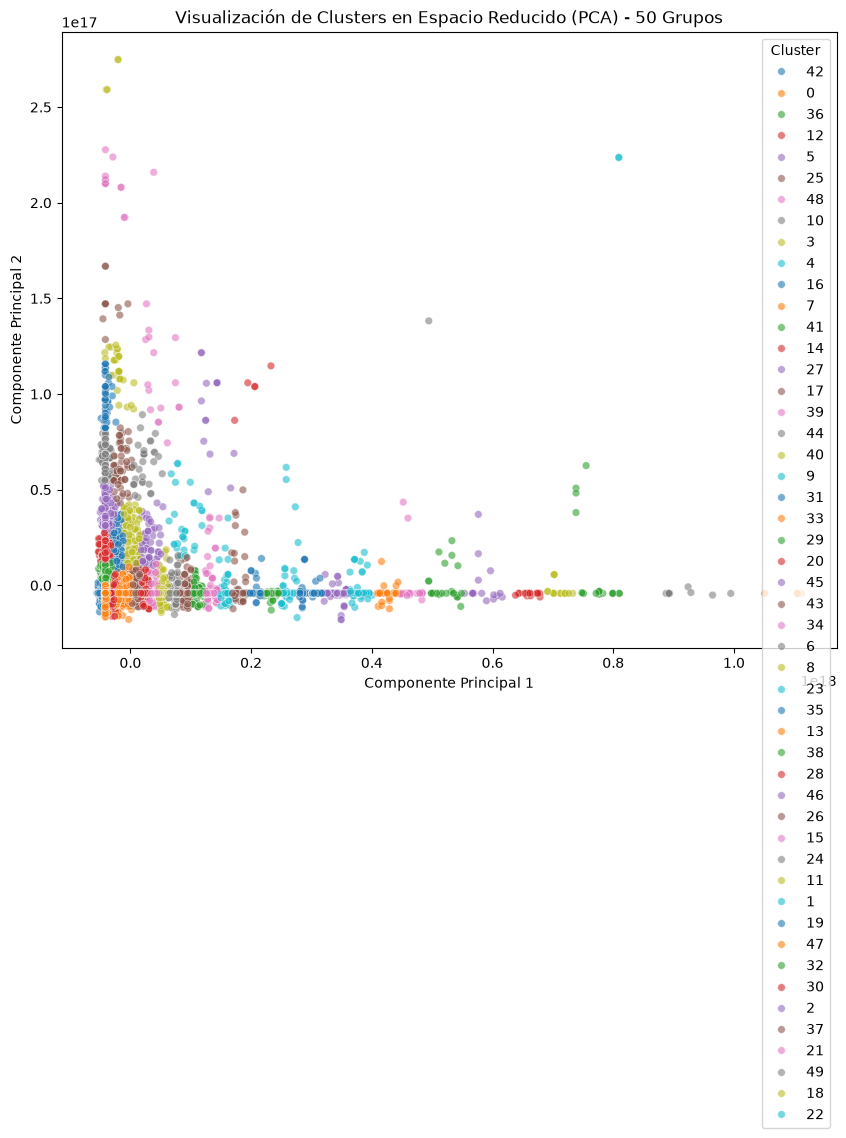

In [43]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. Reducir la dimensionalidad de tus datos a 2D para poder graficarlos
pca = PCA(n_components=2, random_state=SEED)
X_2d = pca.fit_transform(X_anomalia_test) # O puedes usar X_test_enriquecido

# 2. Aplicar un clustering (por ejemplo, K-Means con un número razonable de grupos visuales, ej. 5 u 8)
n_clusters_visuales = 50
kmeans = KMeans(n_clusters=n_clusters_visuales, random_state=SEED, n_init=10)
clusters = kmeans.fit_predict(X_2d)

# 3. Preparar el DataFrame para la visualización con Seaborn
import pandas as pd
df_plot = pd.DataFrame({
    'PCA1': X_2d[:, 0],
    'PCA2': X_2d[:, 1],
    'Cluster': clusters.astype(str)
})

# 4. Graficar
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_plot, 
    x='PCA1', 
    y='PCA2', 
    hue='Cluster', 
    palette='tab10', 
    alpha=0.6, 
    s=30
)
plt.title(f"Visualización de Clusters en Espacio Reducido (PCA) - {n_clusters_visuales} Grupos")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Cluster")
plt.show()

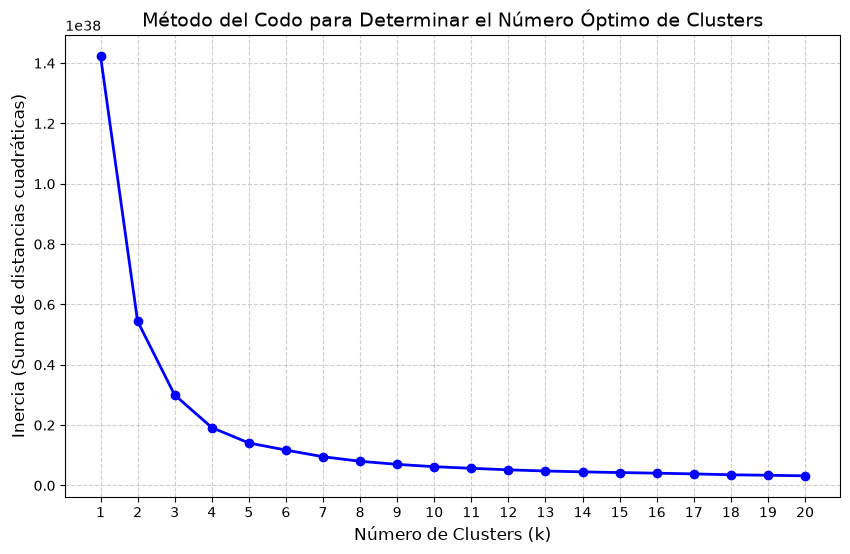

In [44]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Definir un rango razonable de número de clusters a probar (por ejemplo, de 1 a 20)
# Como tienes 53 clases pero quizás se agrupan en menos familias, 20 es un buen tope para buscar el codo.
inercia = []
rango_k = range(1, 21)

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    kmeans.fit(X_anomalia_test) # O puedes usar X_anomalia_train
    inercia.append(kmeans.inertia_)

# 2. Graficar la curva del codo
plt.figure(figsize=(10, 6))
plt.plot(rango_k, inercia, marker='o', linestyle='-', color='b', linewidth=2, markersize=6)
plt.title("Método del Codo para Determinar el Número Óptimo de Clusters", fontsize=14)
plt.xlabel("Número de Clusters (k)", fontsize=12)
plt.ylabel("Inercia (Suma de distancias cuadráticas)", fontsize=12)
plt.xticks(rango_k)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Número óptimo de clusters según la Silueta: 2


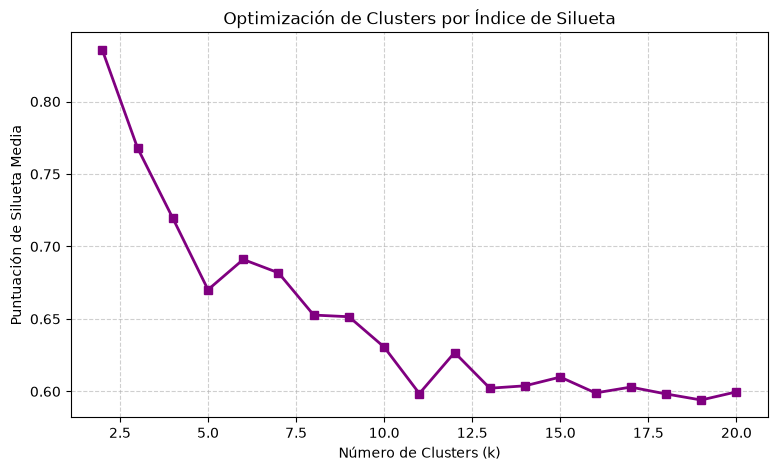

In [45]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Rango de clusters a evaluar (por ejemplo, de 2 a 20)
rango_k = range(2, 21)
valores_silueta = []

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    clusters = kmeans.fit_predict(X_anomalia_test)
    
    # Calcular el coeficiente de silueta medio para este k
    score = silhouette_score(X_anomalia_test, clusters)
    valores_silueta.append(score)

# Encontrar el k que maximiza la silueta
k_optimo_silueta = rango_k[valores_silueta.index(max(valores_silueta))]
print(f"Número óptimo de clusters según la Silueta: {k_optimo_silueta}")

# Gráfica opcional para la memoria del TFM
plt.figure(figsize=(9, 5))
plt.plot(rango_k, valores_silueta, marker='s', color='purple', linestyle='-', linewidth=2)
plt.title("Optimización de Clusters por Índice de Silueta")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Puntuación de Silueta Media")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

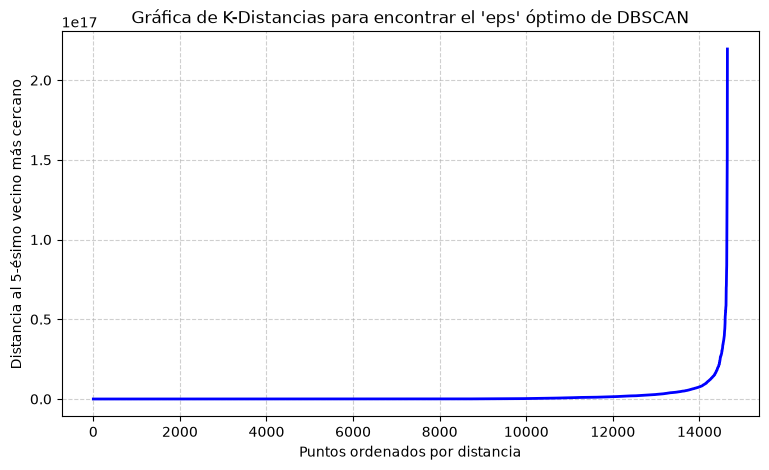


--- RESULTADOS ÓPTIMOS DE DBSCAN ---
Mejor eps encontrado: 28206924266331.7500
Número óptimo de clusters descubiertos: 353
Puntuación de Silueta (sin ruido): 0.9206
Porcentaje de muestras consideradas ruido (-1): 47.72%


In [46]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

# 1. Encontrar automáticamente un valor óptimo de 'eps' usando la gráfica de k-distancias
# k se suele fijar en min_samples - 1 (por ejemplo, si min_samples = 5, k = 4)
min_samples_val = 5
neighbors = NearestNeighbors(n_neighbors=min_samples_val)
neighbors.fit(X_anomalia_test)
distances, _ = neighbors.kneighbors(X_anomalia_test)

# Ordenar las distancias del k-ésimo vecino más cercano de forma ascendente
k_distances = np.sort(distances[:, min_samples_val - 1])

# Visualizar la curva de k-distancias para buscar el "codo" visualmente si se desea
plt.figure(figsize=(9, 5))
plt.plot(k_distances, color='b', linewidth=2)
plt.title("Gráfica de K-Distancias para encontrar el 'eps' óptimo de DBSCAN")
plt.xlabel("Puntos ordenados por distancia")
plt.ylabel(f"Distancia al {min_samples_val}-ésimo vecino más cercano")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. Automatizar una búsqueda rápida de un 'eps' que devuelva un número razonable de clusters válidos
# Probamos un rango de valores para eps basados en los percentiles de las distancias
mejores_clusters = 0
mejor_eps = 0
mejor_silueta = -1
mejor_etiquetas = None

# Probamos con varios umbrales de distancia
rango_eps = np.percentile(k_distances, np.linspace(50, 95, 10))

for eps_val in rango_eps:
    dbscan = DBSCAN(eps=eps_val, min_samples=min_samples_val)
    etiquetas = dbscan.fit_predict(X_anomalia_test)
    
    # Contar cuántos clusters encontró (excluyendo el ruido, que se marca como -1)
    n_clusters_encontrados = len(set(etiquetas)) - (1 if -1 in etiquetas else 0)
    
    # Para calcular la silueta, DBSCAN requiere que haya al menos 2 clusters y que no todo sea ruido (-1)
    if n_clusters_encontrados > 1:
        # Filtramos temporalmente los puntos de ruido (-1) para calcular la silueta de los clusters reales
        mask_no_ruido = etiquetas != -1
        if sum(mask_no_ruido) > n_clusters_encontrados:
            score = silhouette_score(X_anomalia_test[mask_no_ruido], etiquetas[mask_no_ruido])
            
            # Guardamos la mejor combinación según la silueta
            if score > mejor_silueta:
                mejor_silueta = score
                mejor_eps = eps_val
                mejores_clusters = n_clusters_encontrados
                mejor_etiquetas = etiquetas

print(f"\n--- RESULTADOS ÓPTIMOS DE DBSCAN ---")
print(f"Mejor eps encontrado: {mejor_eps:.4f}")
print(f"Número óptimo de clusters descubiertos: {mejores_clusters}")
print(f"Puntuación de Silueta (sin ruido): {mejor_silueta:.4f}")

# Porcentaje de datos clasificados como ruido (etiqueta -1)
if mejor_etiquetas is not None:
    porcentaje_ruido = (sum(mejor_etiquetas == -1) / len(mejor_etiquetas)) * 100
    print(f"Porcentaje de muestras consideradas ruido (-1): {porcentaje_ruido:.2f}%")

### <span style="color:#2ca02c">4.8.2. DBSCAN</span>

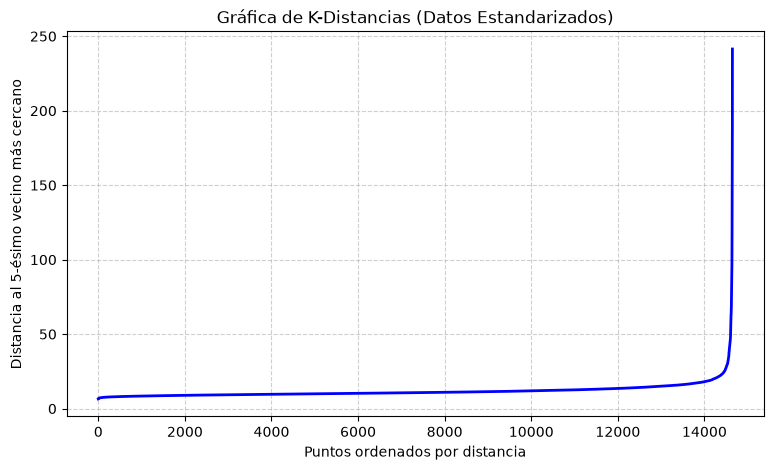


--- RESULTADOS DBSCAN (CON DATOS ESTANDARIZADOS) ---
Mejor eps encontrado: 15.9715
Número óptimo de clusters descubiertos: 18
Puntuación de Silueta (sin ruido): 0.2563
Porcentaje de muestras consideradas ruido (-1): 5.28%


In [47]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

# 1. Estandarizar los datos correctamente
# (Asegúrate de usar el scaler ajustado previamente con tus datos de entrenamiento, 
# o instanciar uno nuevo si es un bloque de análisis exploratorio puro)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_anomalia_test)

# 2. Encontrar automáticamente un valor óptimo de 'eps' usando la gráfica de k-distancias
min_samples_val = 5
neighbors = NearestNeighbors(n_neighbors=min_samples_val)
neighbors.fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)

# Ordenar las distancias del k-ésimo vecino más cercano
k_distances = np.sort(distances[:, min_samples_val - 1])

# Visualizar la curva de k-distancias para verificar el "codo" con los datos escalados
plt.figure(figsize=(9, 5))
plt.plot(k_distances, color='b', linewidth=2)
plt.title("Gráfica de K-Distancias (Datos Estandarizados)")
plt.xlabel("Puntos ordenados por distancia")
plt.ylabel(f"Distancia al {min_samples_val}-ésimo vecino más cercano")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 3. Búsqueda automatizada del mejor 'eps' basada en la silueta y un nivel de ruido razonable
mejores_clusters = 0
mejor_eps = 0
mejor_silueta = -1
mejor_etiquetas = None

# Probamos con varios percentiles del rango de distancias
rango_eps = np.percentile(k_distances, np.linspace(50, 95, 15))

for eps_val in rango_eps:
    dbscan = DBSCAN(eps=eps_val, min_samples=min_samples_val)
    etiquetas = dbscan.fit_predict(X_scaled)
    
    # Contar clusters encontrados (excluyendo el ruido -1)
    n_clusters_encontrados = len(set(etiquetas)) - (1 if -1 in etiquetas else 0)
    
    if n_clusters_encontrados > 1:
        mask_no_ruido = etiquetas != -1
        if sum(mask_no_ruido) > n_clusters_encontrados:
            score = silhouette_score(X_scaled[mask_no_ruido], etiquetas[mask_no_ruido])
            
            if score > mejor_silueta:
                mejor_silueta = score
                mejor_eps = eps_val
                mejores_clusters = n_clusters_encontrados
                mejor_etiquetas = etiquetas

print(f"\n--- RESULTADOS DBSCAN (CON DATOS ESTANDARIZADOS) ---")
print(f"Mejor eps encontrado: {mejor_eps:.4f}")
print(f"Número óptimo de clusters descubiertos: {mejores_clusters}")
print(f"Puntuación de Silueta (sin ruido): {mejor_silueta:.4f}")

if mejor_etiquetas is not None:
    porcentaje_ruido = (sum(mejor_etiquetas == -1) / len(mejor_etiquetas)) * 100
    print(f"Porcentaje de muestras consideradas ruido (-1): {porcentaje_ruido:.2f}%")

--- CÁLCULO AUTOMÁTICO ---
Valor de 'eps' óptimo detectado en el codo: 28.5714

--- RESULTADOS FINALES DE DBSCAN ---
Número de clusters identificados: 8
Porcentaje de muestras consideradas ruido (-1): 0.67%
Puntuación de Silueta (sin ruido): 0.4907


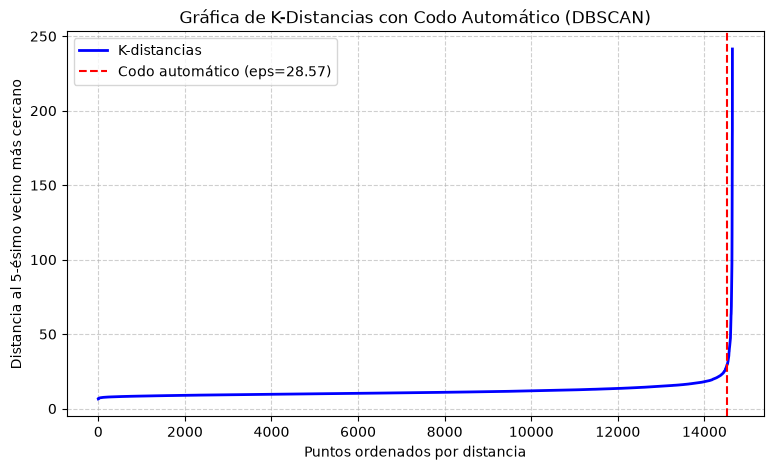

In [39]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator

# 1. Estandarizar los datos correctamente
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_anomalia_test)

# 2. Encontrar las k-distancias para el cálculo automático
min_samples_val = 5
neighbors = NearestNeighbors(n_neighbors=min_samples_val)
neighbors.fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)

# Ordenar las distancias del k-ésimo vecino más cercano
k_distances = np.sort(distances[:, min_samples_val - 1])
puntos_x = np.arange(len(k_distances))

# 3. Detectar automáticamente el "codo" en la curva de K-distancias usando KneeLocator
kneedle = KneeLocator(
    puntos_x, 
    k_distances, 
    curve='convex', 
    direction='increasing'
)

eps_optimo = kneedle.elbow_y

# Si por algún motivo el localizador automático no devolviera un valor, usamos un percentil de seguridad
if eps_optimo is None:
    eps_optimo = np.percentile(k_distances, 95)

print(f"--- CÁLCULO AUTOMÁTICO ---")
print(f"Valor de 'eps' óptimo detectado en el codo: {eps_optimo:.4f}")

# 4. Ejecutar DBSCAN con el 'eps' calculado automáticamente
dbscan = DBSCAN(eps=eps_optimo, min_samples=min_samples_val)
etiquetas = dbscan.fit_predict(X_scaled)

# 5. Analizar los resultados obtenidos
n_clusters_encontrados = len(set(etiquetas)) - (1 if -1 in etiquetas else 0)
porcentaje_ruido = (sum(etiquetas == -1) / len(etiquetas)) * 100

print(f"\n--- RESULTADOS FINALES DE DBSCAN ---")
print(f"Número de clusters identificados: {n_clusters_encontrados}")
print(f"Porcentaje de muestras consideradas ruido (-1): {porcentaje_ruido:.2f}%")

if n_clusters_encontrados > 1:
    mask_no_ruido = etiquetas != -1
    if sum(mask_no_ruido) > n_clusters_encontrados:
        score_silueta = silhouette_score(X_scaled[mask_no_ruido], etiquetas[mask_no_ruido])
        print(f"Puntuación de Silueta (sin ruido): {score_silueta:.4f}")

# 6. Mostrar la gráfica señalando el codo detectado
plt.figure(figsize=(9, 5))
plt.plot(puntos_x, k_distances, color='b', linewidth=2, label='K-distancias')
if kneedle.elbow is not None:
    plt.axvline(x=kneedle.elbow, color='r', linestyle='--', label=f'Codo automático (eps={eps_optimo:.2f})')
plt.title("Gráfica de K-Distancias con Codo Automático (DBSCAN)")
plt.xlabel("Puntos ordenados por distancia")
plt.ylabel(f"Distancia al {min_samples_val}-ésimo vecino más cercano")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [41]:
import pandas as pd
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# 1. Obtener el vector de clasificación (etiquetas predichas por DBSCAN)
# 'etiquetas' es el array que devolvió el modelo DBSCAN (valores de -1 a 7)
vector_clusters = etiquetas

# 2. Crear un DataFrame analítico cruzando los clusters con tus etiquetas reales
df_cruce = pd.DataFrame({
    'Cluster_DBSCAN': vector_clusters,
    'Etiqueta_Real': Y_test_etiquetas  # Asegúrate de que esta variable contenga tus 53 clases reales
})

# 3. Generar la Matriz de Contingencia (Tabla cruzada)
# Filas = Clusters de DBSCAN (incluyendo el -1 como ruido), Columnas = Tus 53 clases reales (o puedes ver una muestra)
matriz_contingencia = pd.crosstab(df_cruce['Cluster_DBSCAN'], df_cruce['Etiqueta_Real'])

print("--- MATRIZ DE CONTINGENCIA (Clusters vs Clases Reales) ---")
print("Dimensiones de la matriz:", matriz_contingencia.shape)
# Mostramos una pequeña porción para visualizarlo cómodamente en consola
print(matriz_contingencia.iloc[:, :]) 

# 4. Calcular métricas de relación / concordancia externa
# (Nota: Omitimos temporalmente el ruido -1 para evaluar qué tan bien agrupados están los puntos válidos)
mask_evaluacion = vector_clusters != -1
if sum(mask_evaluacion) > 0:
    y_real_filtrado = Y_test_etiquetas[mask_evaluacion]
    y_pred_filtrado = vector_clusters[mask_evaluacion]

    ari = adjusted_rand_score(y_real_filtrado, y_pred_filtrado)
    nmi = normalized_mutual_info_score(y_real_filtrado, y_pred_filtrado)

    print(f"\n--- MÉTRICAS DE CONCORDANCIA EXTERNA ---")
    print(f"Adjusted Rand Index (ARI): {ari:.4f}  (0 = azar, 1 = coincidencia perfecta)")
    print(f"Normalized Mutual Information (NMI): {nmi:.4f}  (Mide cuánta información comparten)")

--- MATRIZ DE CONTINGENCIA (Clusters vs Clases Reales) ---
Dimensiones de la matriz: (9, 53)
Etiqueta_Real   access_token_auth_header_error_401  \
Cluster_DBSCAN                                       
-1                                               1   
 0                                             288   
 1                                               0   
 2                                               0   
 3                                               0   
 4                                               1   
 5                                               0   
 6                                               0   
 7                                               0   

Etiqueta_Real   access_token_authorization_form_401  \
Cluster_DBSCAN                                        
-1                                                2   
 0                                              294   
 1                                                0   
 2                                   

# <span style="color:#2ca02c">5. Analisis de importancia de caracteristicas</span>

In [44]:
# 1. Definir un umbral (threshold) basado en el error de entrenamiento o validación
# (Por ejemplo, usando el percentil 95 del error MSE en tu conjunto de entrenamiento 'correct')
reconstructed_train = autoencoder_final.predict(X_correct_train, verbose=0)
train_mse = np.mean(np.square(X_correct_train - reconstructed_train), axis=1)
threshold = np.percentile(train_mse, 95)
print(f"Umbral de anomalía establecido en: {threshold:.6f}")

# 2. Función predictora compatible con scikit-learn / permutation_importance
def predict_autoencoder_labels(estimator, X):
    reconstructed = estimator.predict(X, verbose=0)
    mse = np.mean(np.square(X - reconstructed), axis=1)
    # Si el error supera el umbral es anómalo (-1), si no, es correcto (1)
    predictions = np.where(mse > threshold, -1, 1)
    return predictions

# 3. Función wrapper personalizada para que permutation_importance pueda evaluar el modelo de Keras
from sklearn.base import BaseEstimator, ClassifierMixin

class AutoencoderClassifierWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model, threshold):
        self.model = model
        self.threshold = threshold
        self.classes_ = np.array([-1, 1]) # Requerido por scikit-learn para clasificación binaria
        
    def fit(self, X, y=None):
        return self
        
    def predict(self, X):
        return predict_autoencoder_labels(self.model, X)

# Instanciar el wrapper para el Autoencoder
wrapped_model = AutoencoderClassifierWrapper(autoencoder_final, threshold)

# 4. Preparar Y_test tal como lo tenías
Y_test = df_result.loc[idx_test, 'label'].apply(lambda x: 1 if x == 'correct' else -1).values

# 5. Calcular la importancia de las características por permutación
print("Calculando la importancia de las características...")
result = permutation_importance(
    wrapped_model, X_test, Y_test, 
    scoring='f1',
    n_repeats=5,  # Reducido ligeramente a 5 si el dataset de test es muy grande para acelerar el cálculo
    random_state=SEED, 
    n_jobs=-1
)

# 6. Crear el DataFrame de importancia
df_importancia = pd.DataFrame({
    'Caracteristica': lista_metric_name_vector,
    'Importancia': result.importances_mean
}).sort_values(by='Importancia', ascending=False)

print("\nTop 10 características más importantes para el Autoencoder:")
print(df_importancia.head(10))

Umbral de anomalía establecido en: 0.178090
Calculando la importancia de las características...

Top 10 características más importantes para el Autoencoder:
                                        Caracteristica  Importancia
119           go_gc_duration_seconds_count_diff(lag_1)     0.323987
122          go_memstats_alloc_bytes_total_diff(lag_1)     0.323234
130              go_memstats_mallocs_total_diff(lag_1)     0.320277
197              process_cpu_seconds_total_diff(lag_1)     0.319045
138  net_conntrack_listener_conn_accepted_total_dif...     0.318402
202  prometheus_engine_query_duration_seconds_count...     0.318402
204  prometheus_engine_query_samples_total_diff(lag_1)     0.318402
139  net_conntrack_listener_conn_closed_total_diff(...     0.318402
18                        go_memstats_sys_bytes(lag_0)     0.310376
136                       go_memstats_sys_bytes(lag_1)     0.292340


In [45]:
with pd.option_context('display.max_rows', None):
    display(df_importancia)

,Caracteristica,Importancia
119,go_gc_duration_seconds_count_diff(lag_1),3.239869e-01
122,go_memstats_alloc_bytes_total_diff(lag_1),3.232338e-01
130,go_memstats_mallocs_total_diff(lag_1),3.202770e-01
197,process_cpu_seconds_total_diff(lag_1),3.190445e-01
138,net_conntrack_listener_conn_accepted_total_dif...,3.184020e-01
202,prometheus_engine_query_duration_seconds_count...,3.184020e-01
204,prometheus_engine_query_samples_total_diff(lag_1),3.184020e-01
139,net_conntrack_listener_conn_closed_total_diff(...,3.184020e-01
18,go_memstats_sys_bytes(lag_0),3.103761e-01
136,go_memstats_sys_bytes(lag_1),2.923396e-01


In [47]:
with pd.option_context('display.max_rows', None):
    display(df_importancia)
print(df_importancia[df_importancia['Importancia']<0].shape)
lista_features_poco_importantes=df_importancia[df_importancia['Importancia']<=0]['Caracteristica'].tolist()
#lista_features_poco_importantes = [re.sub(r'\s*\(.*?\)', '', cadena) for cadena in lista_features_poco_importantes]
lista_features_poco_importantes = list(set(lista_features_poco_importantes))
print(len(lista_features_poco_importantes))

,Caracteristica,Importancia
119,go_gc_duration_seconds_count_diff(lag_1),3.239869e-01
122,go_memstats_alloc_bytes_total_diff(lag_1),3.232338e-01
130,go_memstats_mallocs_total_diff(lag_1),3.202770e-01
197,process_cpu_seconds_total_diff(lag_1),3.190445e-01
138,net_conntrack_listener_conn_accepted_total_dif...,3.184020e-01
202,prometheus_engine_query_duration_seconds_count...,3.184020e-01
204,prometheus_engine_query_samples_total_diff(lag_1),3.184020e-01
139,net_conntrack_listener_conn_closed_total_diff(...,3.184020e-01
18,go_memstats_sys_bytes(lag_0),3.103761e-01
136,go_memstats_sys_bytes(lag_1),2.923396e-01


(5, 2)
44


In [49]:
lista_metric_name_reducida_AE=[]
lista_idx_reducida_AE=[]
ID=0
for metric_name in lista_metric_name_vector:
    if not metric_name in lista_features_poco_importantes:
        lista_metric_name_reducida_AE.append(metric_name)
        lista_idx_reducida_AE.append(ID)
    ID+=1
        
        




In [51]:
len(lista_metric_name_reducida_AE)

310

In [33]:
X_matrix_reducida      = X_matrix[:, lista_idx_reducida_IF]
X_correct_train        = X_matrix_reducida[idx_correct_train]
X_test                 = X_matrix_reducida[idx_test]

In [53]:
input_dim = X_correct_train.shape[1]

#1. Recuperamos los parametros de la optimizacion

best_params = study.best_params
print("=== CONFIGURACIÓN DEFINITIVA ===")
print(best_params)

# 2. Instanciar el modelo usando TU función original de creación
#input_dim = X_correct_train.shape[1]
autoencoder_final = create_autoencoder(
    latent_dim=best_params['latent_dim'],
    hidden_units=best_params['hidden_units'],
    learning_rate=best_params['learning_rate'],
    input_dim=input_dim
)

# 3. Configurar Early Stopping con más paciencia para exprimir el entrenamiento
early_stopping_final = EarlyStopping(
    monitor='loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

# 4. Entrenar con un número mayor de épocas (ej: 200) respaldado por tu función
epochs_final = 500

print("\nIniciando entrenamiento del modelo definitivo...")
history_final = autoencoder_final.fit(
    X_correct_train, X_correct_train,
    batch_size=best_params['batch_size'],
    epochs=epochs_final,
    callbacks=[early_stopping_final],
    verbose=1  # verbose=1 para ver la evolución en directo
)

print(f"\n¡Entrenamiento finalizado!")
print(f"Épocas reales ejecutadas: {len(history_final.history['loss'])} / {epochs_final}")
print(f"Loss (MSE) final: {history_final.history['loss'][-1]:.6f}")

=== CONFIGURACIÓN DEFINITIVA ===
{'latent_dim': 32, 'hidden_units': 64, 'learning_rate': 0.005, 'batch_size': 32, 'epochs': 100}

Iniciando entrenamiento del modelo definitivo...
Epoch 1/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2068
Epoch 2/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1629
Epoch 3/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1512
Epoch 4/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1441
Epoch 5/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1395
Epoch 6/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1371
Epoch 7/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1357
Epoch 8/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 986us/step - loss: 0.1339
Epoch 9/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 940us/step - loss: 0.1320
Epoch 10/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1315
Epoch 11/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 945us/step - loss: 0.1307
Epoch 12/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 948us/step - loss: 0

In [54]:
autoencoder = autoencoder_final

In [55]:
# 1. Calculas los errores en el train limpio
reconstructions_train = autoencoder.predict(X_correct_train)
train_scores = np.mean(np.power(X_correct_train - reconstructions_train, 2), axis=1)

# 2. Defines el umbral basándote en el train (ej. el percentil 95 o 99 de los normales)
threshold_percentil_scores = 99.9
threshold = np.percentile(train_scores, threshold_percentil_scores)

320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 596us/step



Calculando errores de reconstrucción en el conjunto de test...
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 578us/step
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 517us/step


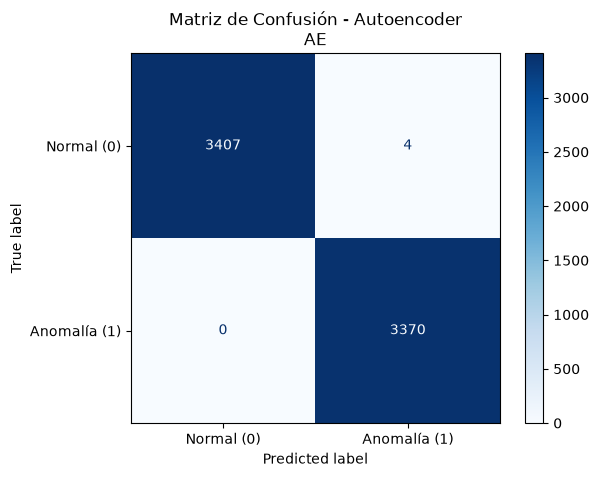

In [56]:
# Calcular los scores (Error de reconstrucción MSE por muestra) para X_test
print("\nCalculando errores de reconstrucción en el conjunto de test...")
reconstructions = autoencoder.predict(X_test)
scores = np.mean(np.power(X_test - reconstructions, 2), axis=1)

reconstructions_train = autoencoder.predict(X_correct_train)
train_scores = np.mean(np.power(X_correct_train - reconstructions_train, 2), axis=1)


# Predicción: Si el MSE supera el umbral es anomalía (1), si no, normal (0)
Y_pred = np.where(scores > threshold, 1, 0)

model_name = f'AE_v1'



df_result[f'result_({model_name})'] = float('nan')
df_result[f'scores_({model_name})'] = float('nan')
df_result.loc[idx_test, f'result_({model_name})'] = Y_pred
df_result.loc[idx_test, f'scores_({model_name})'] = scores

# Mapeo de etiquetas reales (0 = normal/correct, 1 = anomalía)
y_true = df_result.loc[idx_test, 'label'].apply(lambda x: 0 if x == 'correct' else 1)
y_pred = df_result.loc[idx_test, f'result_({model_name})']

# 1. Componentes de la matriz de confusión
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

# 2. Cálculo de métricas
acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = f1_score(y_true, y_pred, zero_division=0)

parametros = best_params.copy()
parametros['threshold_percentil_scores'] = threshold_percentil_scores


# 3. Guardar en el registro
reg_resultado_algoritmo = {
    'test_name': model_name,
    'parametros': json.dumps(parametros),
    'TP': int(tp),
    'FP': int(fp),
    'TN': int(tn),
    'FN': int(fn),
    'accuracy': float(acc),
    'precision': float(precision),
    'recall': float(recall),
    'specificity': float(specificity),
    'f1_score': float(f1)
}

# Si quieres mantener la estructura de lista para un DataFrame posterior:
lista_result.append(reg_resultado_algoritmo)
df_anomaly_detection_summary = pd.DataFrame(lista_result)

# 4. Visualizar la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Anomalía (1)'])
disp.plot(cmap='Blues')
plt.title(f'Matriz de Confusión - Autoencoder\n{model_name}')
plt.show()